In [1]:
# DuckDB for the SQL, requests to pull the file. hashlib and json are for the
# pull manifest: this source refreshes weekly, so "the data" isn't one fixed
# thing and I want a record of which version any given number came from
import duckdb, requests, hashlib, json
from datetime import datetime, timezone
from pathlib import Path

In [2]:
# Download the file and write down what actually came back: when I pulled it,
# what the server said it was, and a hash of the bytes. Weekly refresh means
# there's otherwise no way to tell later which version produced a number
url = "https://canadabuys.canada.ca/opendata/pub/contractHistoryComplete-contratsOctroyesComplet.csv"

# The gateway in front of this endpoint 403s the default python-requests
# User-Agent. Any other string gets through, so this just identifies itself
headers = {"User-Agent": "data-analytics-portfolio/1.0 (public open data pull)"}

data_dir = Path("../data/canadabuys")
data_dir.mkdir(parents=True, exist_ok=True)
target = data_dir / "contractHistoryComplete-contratsOctroyesComplet.csv"

r = requests.get(url, headers=headers, stream=True, timeout=120)
r.raise_for_status()

sha = hashlib.sha256()
size = 0
with open(target, "wb") as f:
    for chunk in r.iter_content(chunk_size=1024 * 1024):
        f.write(chunk)
        sha.update(chunk)
        size += len(chunk)

manifest = {
    "url": url,
    "pulled_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "last_modified": r.headers.get("Last-Modified"),
    "content_length_header": r.headers.get("Content-Length"),
    "bytes_written": size,
    "sha256": sha.hexdigest(),
}
Path("memo/pull_manifest.json").write_text(json.dumps(manifest, indent=2))
manifest

{'url': 'https://canadabuys.canada.ca/opendata/pub/contractHistoryComplete-contratsOctroyesComplet.csv',
 'pulled_at_utc': '2026-09-04T22:16:26+00:00',
 'last_modified': 'Fri, 28 Aug 2026 12:31:43 GMT',
 'content_length_header': '57669819',
 'bytes_written': 57669819,
 'sha256': '1d6c1725a400f51d2a00a15007359399ca5fe59717de9cba5e7be85b9315e11c'}

In [3]:
# Opens (or creates) a local database file to hold the loaded table
con = duckdb.connect("canadabuys.duckdb")

In [4]:
# Everything loads as text. read_csv_auto would guess types here and I'd
# rather make those calls myself at the staging step, where a bad cast shows
# up instead of passing quietly. store_rejects parks anything unreadable in a
# side table so one bad row can't take down the load
con.execute("""
    CREATE OR REPLACE TABLE raw_contract_history AS
    SELECT * FROM read_csv(
        '../data/canadabuys/contractHistoryComplete-contratsOctroyesComplet.csv',
        header = true,
        all_varchar = true,
        store_rejects = true
    )
""")

In [5]:
# Row and column count, a first check on whether what landed matches what the
# source says it publishes
con.sql("""
    SELECT (SELECT COUNT(*) FROM raw_contract_history) AS rows,
           (SELECT COUNT(*) FROM information_schema.columns WHERE table_name = 'raw_contract_history') AS cols
""")

┌───────┬───────┐
│ rows  │ cols  │
│ int64 │ int64 │
├───────┼───────┤
│ 21890 │    91 │
└───────┴───────┘

In [6]:
# Check the column names before writing anything against this table. Headers
# are bilingual and hyphenated, and most fields appear twice with -eng and
# -fra suffixes, so I want the exact spellings rather than my guess at them
print(con.sql("DESCRIBE raw_contract_history").df()[["column_name"]].to_string())

                                                               column_name
0                                                          title-titre-eng
1                                                          title-titre-fra
2                                          referenceNumber-numeroReference
3                                       amendmentNumber-numeroModification
4                                procurementNumber-numeroApprovisionnement
5                                   solicitationNumber-numeroSollicitation
6                                             contractNumber-numeroContrat
7                                    numberOfRecords-nombreEnregistrements
8                                          publicationDate-datePublication
9                                 contractAwardDate-dateAttributionContrat
10                                          amendmentDate-dateModification
11                                      contractStartDate-contratDateDebut
12                       

In [7]:
# Anything DuckDB couldn't read lands here. I expect nothing, since every
# column came in as text and there's no cast to fail, but an empty result is
# worth seeing rather than assuming
con.sql("SELECT line, column_name, error_type, error_message FROM reject_errors")

┌────────┬─────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────┐
│  line  │ column_name │                                                              error_type                                                              │ error_message │
│ uint64 │   varchar   │ enum('cast', 'missing columns', 'too many columns', 'unquoted value', 'line size over maximum', 'invalid encoding', 'invalid state') │    varchar    │
└────────┴─────────────┴──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┴───────────────┘
                                                                                    0 rows                                                                                   

In [8]:
# Short names for the 25 columns I actually use. The file ships 91, most of
# them doubled into -eng and -fra, so this dict is the only place the raw
# bilingual headers appear and everything after it reads the short name.
# contractingEntityName is missing the e on "Entite" in the source itself, so
# the map has to carry the typo.
# Both value columns are here because they sit at different grains.
# totalContractValue is the contract total, repeated on every amendment row.
# contractAmount is what that particular amendment was worth. Summing the
# first across rows is the mistake this project is about.
# amendmentType, amendmentDate and instrumentType arrived in a publisher
# restructuring between March and April 2026, after the header this map was
# first written against. They are why the map is checked against the live
# header rather than trusted: a rename map goes stale against a live source
rename_map = {
    "reference_number":           "referenceNumber-numeroReference",
    "amendment_number":           "amendmentNumber-numeroModification",
    "amendment_type":             "amendmentType-typeModification-eng",
    "amendment_date_raw":         "amendmentDate-dateModification",
    "instrument_type":            "instrumentType-typeInstrument-eng",
    "award_date_raw":             "contractAwardDate-dateAttributionContrat",
    "contract_value_raw":         "totalContractValue-valeurTotaleContrat",
    "contract_amount_raw":        "contractAmount-montantContrat",
    "currency":                   "contractCurrency-contratMonnaie",
    "supplier_legal_name":        "supplierLegalName-nomLegalFournisseur-eng",
    "supplier_standardized_name": "supplierStandardizedName-nomNormaliseFournisseur-eng",
    "supplier_country_raw":       "supplierAddressCountry-fournisseurAdressePays-eng",
    "supplier_province":          "supplierAddressProvince-fournisseurAdresseProvince-eng",
    "supplier_city":              "supplierAddressCity-fournisseurAdresseVille-eng",
    "contracting_entity":         "contractingEntityName-nomEntitContractante-eng",
    "end_user_entity":            "endUserEntitiesName-nomEntitesUtilisateurFinal-eng",
    "unspsc_code":                "unspsc",
    "unspsc_description":         "unspscDescription-eng",
    "gsin_code":                  "gsin-nibs",
    "title_en":                   "title-titre-eng",
    "description_en":             "tenderDescription-descriptionAppelOffres-eng",
    "pct_goods_by_country":       "percentageOfGoodsByCountry-pourcentageDeBiensParPays",
    "procurement_method":         "procurementMethod-methodeApprovisionnement-eng",
    "contract_start_raw":         "contractStartDate-contratDateDebut",
    "contract_end_raw":           "contractEndDate-dateFinContrat",
}

In [9]:
# Build the staging table: short names, types I picked rather than types that
# got guessed, and a row_id so anything can be traced back to the row it came
# from. Nothing is dropped here, that happens later and only with a reason.
# Amendment numbers stay as text because 55 of them aren't numeric at all, so
# the integer version comes back NULL for those and the sort key parks them
# at -1 until I've looked at what they actually are
select_list = ",\n            ".join(f'"{raw}" AS {short}' for short, raw in rename_map.items())

con.execute(f"""
    CREATE OR REPLACE TABLE stg_contract_history AS
    WITH renamed AS (
        SELECT row_number() OVER () AS row_id,
            {select_list}
        FROM raw_contract_history
    ),
    typed AS (
        SELECT *,
            TRY_CAST(award_date_raw AS DATE)                                  AS award_date,
            TRY_CAST(amendment_date_raw AS DATE)                              AS amendment_date,
            TRY_CAST(REPLACE(contract_value_raw, ',', '') AS DECIMAL(18, 2))  AS contract_value_cad,
            TRY_CAST(REPLACE(contract_amount_raw, ',', '') AS DECIMAL(18, 2)) AS contract_amount_cad,
            CASE WHEN regexp_matches(amendment_number, '^[0-9]{{3}}$')
                 THEN CAST(amendment_number AS INTEGER) END                   AS amendment_no_int
        FROM renamed
    )
    SELECT *, COALESCE(amendment_no_int, -1) AS amendment_sort_key
    FROM typed
""")

In [10]:
# Check the casts landed where I meant them to, mainly that value came out a
# decimal and the date came out a date rather than staying text
con.sql("DESCRIBE stg_contract_history")

┌──────────────────────┬───────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name      │  column_type  │  null   │   key   │ default │  extra  │
│       varchar        │    varchar    │ varchar │ varchar │ varchar │ varchar │
├──────────────────────┼───────────────┼─────────┼─────────┼─────────┼─────────┤
│ row_id               │ BIGINT        │ YES     │ NULL    │ NULL    │ NULL    │
│ reference_number     │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ amendment_number     │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ amendment_type       │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ amendment_date_raw   │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ instrument_type      │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ award_date_raw       │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ contract_value_raw   │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ contract_amount_raw  │ VAR

In [11]:
# Staging should be exactly as tall as raw. If these differ then something in
# the rename or the CTEs is quietly filtering, and I'd rather catch that here
# than three tables downstream
con.sql("""
    SELECT (SELECT COUNT(*) FROM stg_contract_history) AS stg_rows,
           (SELECT COUNT(*) FROM raw_contract_history) AS raw_rows
""")

┌──────────┬──────────┐
│ stg_rows │ raw_rows │
│  int64   │  int64   │
├──────────┼──────────┤
│    21890 │    21890 │
└──────────┴──────────┘

In [12]:
# Every assertion is one query that returns the rows that failed it. This
# helper counts them, files the result in a table I can render at the end,
# and hands back the first few so I can look at what actually failed instead
# of trusting a count. Delete-then-insert means re-running a rule updates its
# row rather than stacking a second one.
# Writing the expected count in at the call site is on purpose: this runs
# against a file that refreshes weekly, and a rule that quietly changes shape
# between pulls should be obvious rather than something I have to go looking for.
# BLOCK now stops the notebook instead of just printing in red. It used to only
# label the failure, and when the country crosswalk broke, four more layers got
# built on top of it before anyone noticed. blocks_above is per rule because a
# couple of them tolerate a known count: there is one negative contract in this
# file and it is already dealt with, so only a second one is news
con.execute("""
    CREATE OR REPLACE TABLE dq_assertions (
        id VARCHAR, severity VARCHAR, rule VARCHAR, expected VARCHAR,
        failing_rows BIGINT, pct_of_rows DOUBLE, decision VARCHAR
    )
""")

n_rows = con.sql("SELECT COUNT(*) FROM stg_contract_history").fetchone()[0]

def assert_rule(rule_id, severity, rule, expected, failing_sql, decision, show=5, blocks_above=0):
    n = con.sql(f"SELECT COUNT(*) FROM ({failing_sql})").fetchone()[0]
    con.execute("DELETE FROM dq_assertions WHERE id = ?", [rule_id])
    con.execute("INSERT INTO dq_assertions VALUES (?, ?, ?, ?, ?, ?, ?)",
                [rule_id, severity, rule, expected, n, round(100.0 * n / n_rows, 2), decision])
    print(f"{rule_id} {severity}: {n} rows ({100.0 * n / n_rows:.2f}%), expected {expected}")
    if severity == "BLOCK" and n > blocks_above:
        raise AssertionError(
            f"{rule_id} failed with {n} rows, above the {blocks_above} this rule tolerates. "
            f"Rule: {rule}. Decision on record: {decision}. "
            f"Nothing below this cell should be run until it is resolved."
        )
    return con.sql(f"SELECT * FROM ({failing_sql}) LIMIT {show}")

In [13]:
# A1: the contract key. Everything downstream assumes one row per contract
# per amendment, and the dedup in particular is built on that, so if this
# isn't unique there's no point continuing
assert_rule("A1", "BLOCK", "duplicate (reference_number, amendment_number)", "0",
    """SELECT reference_number, amendment_number, COUNT(*) AS n
       FROM stg_contract_history GROUP BY 1, 2 HAVING COUNT(*) > 1""",
    "stop if any")

A1 BLOCK: 0 rows (0.00%), expected 0


┌──────────────────┬──────────────────┬───────┐
│ reference_number │ amendment_number │   n   │
│     varchar      │     varchar      │ int64 │
└──────────────────┴──────────────────┴───────┘
                    0 rows                   

In [14]:
# A2: anything DuckDB rejected at load. Same reject table I looked at
# earlier, except now the count goes on the record instead of just being
# glanced at, so a future pull that starts rejecting rows is visible
assert_rule("A2", "BLOCK", "rows rejected at load (invalid UTF-8)", "at most 4",
    "SELECT line, column_name, error_type FROM reject_errors",
    "stored, counted, carried", blocks_above=4)

A2 BLOCK: 0 rows (0.00%), expected at most 4


┌────────┬─────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  line  │ column_name │                                                              error_type                                                              │
│ uint64 │   varchar   │ enum('cast', 'missing columns', 'too many columns', 'unquoted value', 'line size over maximum', 'invalid encoding', 'invalid state') │
└────────┴─────────────┴──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘
                                                                            0 rows                                                                           

In [15]:
# A3: amendment numbers that aren't three digits. These are exactly the rows
# a plain TRY_CAST would have turned into NULL without mentioning it, which is
# why the integer version is a CASE on a regex rather than a bare cast
assert_rule("A3", "WARN", "amendment_number not three digits", "55",
    """SELECT row_id, reference_number, amendment_number, award_date, contract_value_cad
       FROM stg_contract_history WHERE amendment_no_int IS NULL""",
    "non-numeric codes sort first; measured both ways, 0 contracts change", show=10)

A3 WARN: 55 rows (0.25%), expected 55


┌────────┬─────────────────────┬──────────────────┬────────────┬────────────────────┐
│ row_id │  reference_number   │ amendment_number │ award_date │ contract_value_cad │
│ int64  │       varchar       │     varchar      │    date    │   decimal(18,2)    │
├────────┼─────────────────────┼──────────────────┼────────────┼────────────────────┤
│  11287 │ EN578-172870/014/ZN │ T01              │ NULL       │               0.00 │
│  11288 │ EN578-172870/050/ZN │ T01              │ NULL       │               0.00 │
│  11289 │ EN578-172870/099/ZN │ T01              │ NULL       │               0.00 │
│  11290 │ EN578-172870/166/ZN │ T01              │ NULL       │               0.00 │
│  11291 │ EN578-172870/212/ZN │ T01              │ NULL       │               0.00 │
│  11293 │ EN966-140305/042/ZF │ T01              │ NULL       │               0.00 │
│  11354 │ EN966-140305/208/ZF │ T01              │ NULL       │               0.00 │
│  11591 │ EN966-140305/005/ZF │ T01              │ NU

In [16]:
# Before deciding where the non-numeric codes sort, look at what they are.
# For each one: does the same contract also carry numeric amendments, and if
# so where do those sit in time and value? A code that's the only row on its
# contract can't be affected by the sort order at all, so the decision only
# really applies to whatever's left
con.sql("""
    WITH nn AS (
        SELECT reference_number, amendment_number AS nn_code, award_date AS nn_date, contract_value_cad AS nn_value
        FROM stg_contract_history WHERE amendment_no_int IS NULL)
    SELECT nn.reference_number, nn.nn_code, nn.nn_date, nn.nn_value,
           COUNT(s.row_id)           AS numeric_rows,
           MAX(s.amendment_no_int)   AS max_numeric_amendment,
           MAX(s.award_date)         AS latest_numeric_date,
           MAX(s.contract_value_cad) AS max_numeric_value
    FROM nn LEFT JOIN stg_contract_history s
      ON s.reference_number = nn.reference_number AND s.amendment_no_int IS NOT NULL
    GROUP BY 1, 2, 3, 4
    ORDER BY numeric_rows DESC, nn.reference_number
""")

┌──────────────────────┬─────────┬────────────┬───────────────┬──────────────┬───────────────────────┬─────────────────────┬───────────────────┐
│   reference_number   │ nn_code │  nn_date   │   nn_value    │ numeric_rows │ max_numeric_amendment │ latest_numeric_date │ max_numeric_value │
│       varchar        │ varchar │    date    │ decimal(18,2) │    int64     │         int32         │        date         │   decimal(18,2)   │
├──────────────────────┼─────────┼────────────┼───────────────┼──────────────┼───────────────────────┼─────────────────────┼───────────────────┤
│ EN960-231030/101/ZF  │ T01     │ 2023-09-25 │       2237.00 │            3 │                     2 │ 2023-09-25          │           2237.00 │
│ W7714-228152/001/QF  │ T01     │ 2025-03-05 │          0.00 │            3 │                     2 │ 2025-03-05          │              0.00 │
│ EP745-241648/001/ZF  │ T01     │ 2024-02-06 │      15826.00 │            2 │                     1 │ 2024-02-06          │      

In [17]:
# A4: rows where the raw text is present but the cast came back empty. This
# is what separates "the field is blank" from "the field is in a format I
# didn't anticipate", and only the second one is actually a problem
assert_rule("A4", "WARN", "raw value/date non-empty but typed cast is NULL", "0",
    """SELECT row_id, contract_value_raw, contract_value_cad, award_date_raw, award_date
       FROM stg_contract_history
       WHERE (NULLIF(TRIM(contract_value_raw), '') IS NOT NULL AND contract_value_cad IS NULL)
          OR (NULLIF(TRIM(award_date_raw), '') IS NOT NULL AND award_date IS NULL)""",
    "inspect if any")

A4 WARN: 0 rows (0.00%), expected 0


┌────────┬────────────────────┬────────────────────┬────────────────┬────────────┐
│ row_id │ contract_value_raw │ contract_value_cad │ award_date_raw │ award_date │
│ int64  │      varchar       │   decimal(18,2)    │    varchar     │    date    │
└────────┴────────────────────┴────────────────────┴────────────────┴────────────┘
                                      0 rows                                    

In [18]:
# A5: zero-value rows, and there are a lot of them. Keeping them, they're
# real award records, but they come out of anything that shares value around
# and stay in anything counting contracts
assert_rule("A5", "WARN", "contract_value_cad = 0", "5,502 (25.1%)",
    "SELECT row_id, reference_number, amendment_number, contract_value_cad FROM stg_contract_history WHERE contract_value_cad = 0",
    "keep, flag, exclude from value shares; mostly standing offers and supply arrangements, see A24")

A5 WARN: 5502 rows (25.13%), expected 5,502 (25.1%)


┌────────┬──────────────────────┬──────────────────┬────────────────────┐
│ row_id │   reference_number   │ amendment_number │ contract_value_cad │
│ int64  │       varchar        │     varchar      │   decimal(18,2)    │
├────────┼──────────────────────┼──────────────────┼────────────────────┤
│     74 │ W8486-21XA32/001/BK  │ 000              │               0.00 │
│    159 │ E60QD-250036/001/QD  │ 000              │               0.00 │
│    175 │ M7594-223663/001/CAG │ 000              │               0.00 │
│    187 │ M7594-234222/001/BM  │ 000              │               0.00 │
│    216 │ F7047-231212/001/ERD │ 000              │               0.00 │
└────────┴──────────────────────┴──────────────────┴────────────────────┘

In [19]:
# A6: negative values. Only one of them, but this is a BLOCK because a
# negative dropped into a SUM doesn't announce itself, it just quietly makes
# every total smaller
assert_rule("A6", "BLOCK", "contract_value_cad below 0", "1",
    "SELECT row_id, reference_number, amendment_number, contract_value_cad, supplier_legal_name FROM stg_contract_history WHERE contract_value_cad < 0",
    "quarantine, exclude from value", blocks_above=1)

A6 BLOCK: 1 rows (0.00%), expected 1


┌────────┬──────────────────────┬──────────────────┬────────────────────┬───────────────────────────────────────────────┐
│ row_id │   reference_number   │ amendment_number │ contract_value_cad │              supplier_legal_name              │
│ int64  │       varchar        │     varchar      │   decimal(18,2)    │                    varchar                    │
├────────┼──────────────────────┼──────────────────┼────────────────────┼───────────────────────────────────────────────┤
│  17703 │ W8482-029D1C/001/USW │ 005              │        -6868536.00 │ UNITED STATES DEPARTMENT OF THE NAVY (SPAWAR) │
└────────┴──────────────────────┴──────────────────┴────────────────────┴───────────────────────────────────────────────┘

In [20]:
# A7: anything over $100M. Not wrong on its own, contracts that size exist here, but worth reading the top of the list to check they look like real
# awards rather than a decimal point in the wrong place
assert_rule("A7", "NOTE", "contract_value_cad above 100,000,000", "115",
    """SELECT reference_number, amendment_number, contract_value_cad, supplier_legal_name, award_date
       FROM stg_contract_history WHERE contract_value_cad > 100000000 ORDER BY contract_value_cad DESC""",
    "keep, eyeball top 20", show=20)

A7 NOTE: 115 rows (0.53%), expected 115


┌──────────────────────┬──────────────────┬────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────┬────────────┐
│   reference_number   │ amendment_number │ contract_value_cad │                                    supplier_legal_name                                     │ award_date │
│       varchar        │     varchar      │   decimal(18,2)    │                                          varchar                                           │    date    │
├──────────────────────┼──────────────────┼────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────┼────────────┤
│ CW2465774            │ 000              │     13044299191.04 │ Chantier Davie Canada Inc.                                                                 │ 2026-08-23 │
│ F7017-251202/001/NQ  │ 000              │      3745829208.24 │ Chantier Davie Canada Inc.                                                      

In [21]:
# A10: rows where the country is the literal string "N/A". Not a null, an
# actual value the publisher wrote, which means a filter on country silently
# drops it rather than flagging it. Resolved later by the same-name rule
assert_rule("A10", "WARN", "supplier_country_raw is N/A", "count",
    "SELECT row_id, supplier_legal_name, supplier_country_raw, contract_value_cad FROM stg_contract_history WHERE supplier_country_raw = 'N/A'",
    "resolve by same-name-elsewhere rule, else unknown")

A10 WARN: 1 rows (0.00%), expected count


┌────────┬────────────────────────────────┬──────────────────────┬────────────────────┐
│ row_id │      supplier_legal_name       │ supplier_country_raw │ contract_value_cad │
│ int64  │            varchar             │       varchar        │   decimal(18,2)    │
├────────┼────────────────────────────────┼──────────────────────┼────────────────────┤
│  17153 │ KNDS Deutschland GmbH & Co. KG │ N/A                  │       654902379.00 │
└────────┴────────────────────────────────┴──────────────────────┴────────────────────┘

In [22]:
# A11: this file is meant to be one department's awards. If a third
# contracting entity turns up then the scope I'm claiming in the memo is
# wrong, so it's worth asserting rather than assuming
assert_rule("A11", "WARN", "contracting_entity is not one of the two PSPC spellings", "0",
    """SELECT row_id, contracting_entity FROM stg_contract_history
       WHERE contracting_entity NOT IN ('Department of Public Works and Government Services (PSPC)',
                                        'Public Works and Government Services Canada')""",
    "documents scope")

A11 WARN: 0 rows (0.00%), expected 0


┌────────┬────────────────────┐
│ row_id │ contracting_entity │
│ int64  │      varchar       │
└────────┴────────────────────┘
            0 rows           

In [23]:
# A12: every end-user string that mentions defence in either language. The
# defence subset gets picked from this list rather than from a name I assumed,
# and it needs to be a substring match because one cell can carry several
# bodies separated by slashes
con.sql("""
    SELECT end_user_entity, COUNT(*) AS rows, SUM(contract_value_cad) AS raw_value
    FROM stg_contract_history
    WHERE lower(end_user_entity) LIKE '%defence%' OR lower(end_user_entity) LIKE '%défense%' OR lower(end_user_entity) LIKE '%defense%'
       OR lower(end_user_entity) LIKE '%armed forces%' OR lower(end_user_entity) LIKE '%forces armées%'
    GROUP BY 1 ORDER BY rows DESC
""")

┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [24]:
# A13: contracts with no UNSPSC code. These can't be segmented by category,
# so rather than dropping them they get their own "unclassified" bucket and
# the memo says how big it is
assert_rule("A13", "WARN", "unspsc_code null", "about 1,762 (8.0%)",
    "SELECT row_id, reference_number, description_en FROM stg_contract_history WHERE NULLIF(TRIM(unspsc_code), '') IS NULL",
    "segment unclassified; every one is a legacy-format record, see A26")

A13 WARN: 1762 rows (8.05%), expected about 1,762 (8.0%)


┌────────┬──────────────────────┬────────────────┐
│ row_id │   reference_number   │ description_en │
│ int64  │       varchar        │    varchar     │
├────────┼──────────────────────┼────────────────┤
│      1 │ F7017-251202/001/NQ  │ NULL           │
│      2 │ F7044-221317/001/ML  │ NULL           │
│      3 │ F1802-220005/001/MER │ NULL           │
│      4 │ F7044-230296/001/MER │ NULL           │
│      5 │ T5013-230002/001/MER │ NULL           │
└────────┴──────────────────────┴────────────────┘

In [25]:
# A14: GSIN, the other classification field. Populated so rarely it can't
# carry any analysis, which is the reason segmentation runs on UNSPSC instead.
# Recorded so that choice is evidenced rather than asserted
assert_rule("A14", "NOTE", "gsin_code null", "about 91.7%",
    "SELECT row_id FROM stg_contract_history WHERE NULLIF(TRIM(gsin_code), '') IS NULL",
    "not used")

A14 NOTE: 20082 rows (91.74%), expected about 91.7%


┌────────┐
│ row_id │
│ int64  │
├────────┤
│    645 │
│    646 │
│    647 │
│    648 │
│    649 │
└────────┘

In [26]:
# A15: the Canadian content field. This is the one column that would answer
# the question the whole project is about, and it is the headline of the memo
# precisely because of what this returns
assert_rule("A15", "NOTE", "pct_goods_by_country null", "21,890 (100%)",
    "SELECT row_id FROM stg_contract_history WHERE NULLIF(TRIM(pct_goods_by_country), '') IS NULL",
    "reading C not computable")

A15 NOTE: 21890 rows (100.00%), expected 21,890 (100%)


┌────────┐
│ row_id │
│ int64  │
├────────┤
│      1 │
│      2 │
│      3 │
│      4 │
│      5 │
└────────┘

In [27]:
# A16: the publisher's own standardized supplier name. Too sparse to use as
# a ground truth for name matching, which is why the normaliser later is
# deterministic and reviewable rather than scored against this
assert_rule("A16", "NOTE", "supplier_standardized_name null", "about 76.8%",
    "SELECT row_id FROM stg_contract_history WHERE NULLIF(TRIM(supplier_standardized_name), '') IS NULL",
    "not used")

A16 NOTE: 16814 rows (76.81%), expected about 76.8%


┌────────┐
│ row_id │
│ int64  │
├────────┤
│    645 │
│    646 │
│    648 │
│    649 │
│    650 │
└────────┘

In [28]:
# A17: award dates outside the window this file is supposed to cover. A date
# in the future or before the series starts would mean either a data entry
# problem or that I've misread what the column is
assert_rule("A17", "WARN", "award_date outside 2023-06-01 to today", "0",
    "SELECT row_id, award_date FROM stg_contract_history WHERE award_date < DATE '2023-06-01' OR award_date > current_date",
    "inspect if any")

A17 WARN: 0 rows (0.00%), expected 0


┌────────┬────────────┐
│ row_id │ award_date │
│ int64  │    date    │
└────────┴────────────┘
        0 rows       

In [29]:
# A20: award dates that are missing altogether. A17 only catches dates that
# are present and wrong, so without this the gaps go unrecorded, and one of
# them sits on a contract worth over a billion
assert_rule("A20", "WARN", "award_date null", "305",
    "SELECT row_id, reference_number, contract_value_cad FROM stg_contract_history WHERE award_date IS NULL ORDER BY contract_value_cad DESC",
    "kept, excluded from date-based cuts; every one is a legacy-format record with no original row, see A25 and A26")

A20 WARN: 305 rows (1.39%), expected 305


┌────────┬─────────────────────┬────────────────────┐
│ row_id │  reference_number   │ contract_value_cad │
│ int64  │       varchar       │   decimal(18,2)    │
├────────┼─────────────────────┼────────────────────┤
│  12075 │ W3373-000002/001/FS │      1772435005.00 │
│  15432 │ W3373-000002/001/FS │      1772435005.00 │
│  13918 │ W8472-075091/002/FX │       786061178.00 │
│  11960 │ W8482-079120/001/FX │       600758699.00 │
│  12286 │ W8482-079120/001/FX │       600758699.00 │
└────────┴─────────────────────┴────────────────────┘

In [30]:
# A18: any currency other than CAD. If this ever fires then every total in
# the memo is adding up different units, so it stays in even though it has
# never returned anything
assert_rule("A18", "WARN", "currency not CAD", "0",
    "SELECT currency, COUNT(*) AS n FROM stg_contract_history WHERE currency <> 'CAD' GROUP BY 1",
    "inspect if any")

A18 WARN: 0 rows (0.00%), expected 0


┌──────────┬───────┐
│ currency │   n   │
│ varchar  │ int64 │
└──────────┴───────┘
       0 rows     

In [31]:
# The suite as it stands. A8, A9 and A19 join it later, once the dedup and
# the crosswalks they test actually exist. Sorting on the number rather than
# the string, otherwise A10 lands between A1 and A2 and the table reads badly
# in the memo
con.sql("SELECT * FROM dq_assertions ORDER BY CAST(substr(id, 2) AS INTEGER)")

┌─────────┬──────────┬─────────────────────────────────────────────────────────┬────────────────────┬──────────────┬─────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│   id    │ severity │                          rule                           │      expected      │ failing_rows │ pct_of_rows │                                                    decision                                                    │
│ varchar │ varchar  │                         varchar                         │      varchar       │    int64     │   double    │                                                    varchar                                                     │
├─────────┼──────────┼─────────────────────────────────────────────────────────┼────────────────────┼──────────────┼─────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ A1      │ BLOCK    │ d

In [32]:
# Draft the country crosswalk. Two-letter codes pass straight through since
# they're already what I want, the long names need an iso2 written in by hand,
# and N/A and blank stay empty because there's nothing to map them to.
# This merges, it does not overwrite. The source refreshes weekly and can
# introduce a country value that wasn't there before, so the draft has to be
# rebuilt every run. But rebuilding it must never wipe codes already reviewed,
# which is exactly what an earlier version of this cell did: a clean run from
# the top silently blanked the file and the borrow rule downstream then
# invented countries for 1,760 rows without erroring. Reviewed values win,
# anything new arrives blank, and A9 refuses to let it through unnoticed
con.execute("""
    CREATE OR REPLACE TABLE country_crosswalk_draft AS
    SELECT CASE WHEN NULLIF(TRIM(supplier_country_raw), '') IS NULL THEN '(blank)'
                ELSE supplier_country_raw END AS raw_value,
           COUNT(*) AS rows,
           CASE WHEN regexp_matches(supplier_country_raw, '^[A-Z]{2}$') THEN supplier_country_raw END AS iso2_auto,
           CASE WHEN regexp_matches(supplier_country_raw, '^[A-Z]{2}$') THEN 'iso2_passthrough'
                WHEN supplier_country_raw = 'N/A' THEN 'na'
                WHEN NULLIF(TRIM(supplier_country_raw), '') IS NULL THEN 'blank'
                ELSE 'long_name' END AS rule
    FROM stg_contract_history
    GROUP BY 1, 3, 4
""")

cw_path = Path("crosswalks/country_crosswalk.csv")
if cw_path.exists():
    con.execute("CREATE OR REPLACE TABLE country_crosswalk_prior AS SELECT * FROM read_csv('crosswalks/country_crosswalk.csv', header = true, all_varchar = true)")
    crosswalk_sql = """
        SELECT d.raw_value, d.rows,
               COALESCE(NULLIF(TRIM(p.iso2), ''), d.iso2_auto, '') AS iso2, d.rule,
               COALESCE(p.country_name, '')                        AS country_name,
               COALESCE(NULLIF(TRIM(p.confidence), ''), 'high')    AS confidence,
               COALESCE(p.note, '')                                AS note
        FROM country_crosswalk_draft d
        LEFT JOIN country_crosswalk_prior p USING (raw_value)"""
else:
    crosswalk_sql = """
        SELECT raw_value, rows, COALESCE(iso2_auto, '') AS iso2, rule,
               '' AS country_name, 'high' AS confidence, '' AS note
        FROM country_crosswalk_draft"""

con.execute(f"COPY ({crosswalk_sql} ORDER BY rows DESC) TO 'crosswalks/country_crosswalk.csv' (HEADER)")

con.sql(f"{crosswalk_sql} ORDER BY rows DESC")

┌────────────────┬───────┬─────────┬──────────────────┬────────────────┬────────────┬───────────────────────────────────────────────────────┐
│   raw_value    │ rows  │  iso2   │       rule       │  country_name  │ confidence │                         note                          │
│    varchar     │ int64 │ varchar │     varchar      │    varchar     │  varchar   │                        varchar                        │
├────────────────┼───────┼─────────┼──────────────────┼────────────────┼────────────┼───────────────────────────────────────────────────────┤
│ CA             │ 18315 │ CA      │ iso2_passthrough │ Canada         │ high       │                                                       │
│ Canada         │  1488 │ CA      │ long_name        │ Canada         │ high       │ long name mapped to ISO 3166-1 alpha-2                │
│ US             │  1357 │ US      │ iso2_passthrough │ United States  │ high       │                                                       │
│ Unit

In [33]:
# Load the reviewed crosswalk back in and prove it covers every country value
# in the file (A9). The join normalises blanks the same way the draft did,
# otherwise the three empty-string rows come back as uncovered with no obvious
# reason why. N/A and blank are allowed to have no iso2, everything else isn't
con.execute("CREATE OR REPLACE TABLE country_crosswalk AS SELECT * FROM read_csv('crosswalks/country_crosswalk.csv', header = true, all_varchar = true)")

assert_rule("A9", "BLOCK", "supplier_country_raw not covered by country_crosswalk.csv", "0",
    """WITH s AS (
           SELECT CASE WHEN NULLIF(TRIM(supplier_country_raw), '') IS NULL THEN '(blank)'
                       ELSE supplier_country_raw END AS raw_value
           FROM stg_contract_history)
       SELECT s.raw_value, COUNT(*) AS n
       FROM s LEFT JOIN country_crosswalk c USING (raw_value)
       WHERE c.raw_value IS NULL
          OR (c.rule NOT IN ('na', 'blank') AND NULLIF(TRIM(c.iso2), '') IS NULL)
       GROUP BY 1""",
    "extend the crosswalk until 0")

A9 BLOCK: 0 rows (0.00%), expected 0


┌───────────┬───────┐
│ raw_value │   n   │
│  varchar  │ int64 │
└───────────┴───────┘
       0 rows      

In [34]:
# A23: rows with no supplier name at all. The export reconciliation found one
# contract fewer than the quarantine explained, and this is where it went: a
# legal name that is null gets a null name key, and a join on a null key
# matches nothing, so the row falls out of every table built through
# dim_supplier without anything saying so. Recorded here rather than patched
# in the export, because the same join sits inside the sensitivity and segment
# marts and a contract count that is quietly one short is still wrong. The
# name-key cell below gives these rows an explicit blank key, the same
# treatment blank countries and blank end users already get
assert_rule("A23", "WARN", "supplier_legal_name null or blank", "1",
    """SELECT row_id, reference_number, amendment_number, award_date, contract_value_cad,
              supplier_country_raw, end_user_entity, procurement_method, title_en
       FROM stg_contract_history WHERE NULLIF(TRIM(supplier_legal_name), '') IS NULL""",
    "kept under an explicit (blank) supplier key")

A23 WARN: 1 rows (0.00%), expected 1


┌────────┬──────────────────┬──────────────────┬────────────┬────────────────────┬──────────────────────┬──────────────────────────────────────┬────────────────────────────┬──────────────────────────┐
│ row_id │ reference_number │ amendment_number │ award_date │ contract_value_cad │ supplier_country_raw │           end_user_entity            │     procurement_method     │         title_en         │
│ int64  │     varchar      │     varchar      │    date    │   decimal(18,2)    │       varchar        │               varchar                │          varchar           │         varchar          │
├────────┼──────────────────┼──────────────────┼────────────┼────────────────────┼──────────────────────┼──────────────────────────────────────┼────────────────────────────┼──────────────────────────┤
│  10175 │ CW2422761        │ 000              │ 2025-10-24 │               0.00 │ NULL                 │ Department of National Defence (DND) │ Competitive - Open bidding │ UGME W6369-23A065-009-

In [35]:
# A deterministic key for grouping the same company written different ways:
# strip accents, upper-case, throw away punctuation, drop the legal-form
# words, join what's left. Nothing fuzzy about it, so every grouping it makes
# can be read and argued with rather than tuned until it looks right.
# LIMITEE and LIMITE are in the list because this file is bilingual and Bell
# Textron Canada, the largest defence supplier in it, is written both ways.
# The COALESCE at the end catches names with no Latin characters at all, which
# would otherwise every one of them normalise to the same empty string
con.execute("""
    CREATE OR REPLACE MACRO name_key(s) AS COALESCE(NULLIF(
      array_to_string(
        list_filter(
          string_split(regexp_replace(strip_accents(upper(s)), '[^A-Z0-9]', ' ', 'g'), ' '),
          w -> w <> '' AND w NOT IN ('LIMITED','LTD','LTEE','LIMITEE','LIMITE','INC','INCORPORATED',
                                     'CORP','CORPORATION','CO','COMPANY','COMPAGNIE','CIE','ULC','LLC',
                                     'LP','LLP','SENC','SEC','ENR','GMBH','SA','SAS','BV','NV','PLC','AG','THE')
        ), ''), ''), upper(TRIM(s)))
""")

con.execute("ALTER TABLE stg_contract_history ADD COLUMN IF NOT EXISTS supplier_name_key VARCHAR")
con.execute("UPDATE stg_contract_history SET supplier_name_key = COALESCE(name_key(NULLIF(TRIM(supplier_legal_name), '')), '(blank)')")

con.sql("""
    SELECT COUNT(DISTINCT supplier_legal_name) AS legal_names,
           COUNT(DISTINCT supplier_name_key)   AS name_keys
    FROM stg_contract_history
""")

┌─────────────┬───────────┐
│ legal_names │ name_keys │
│    int64    │   int64   │
├─────────────┼───────────┤
│        6558 │      6227 │
└─────────────┴───────────┘

In [36]:
# The blank normalisation gets used in three different places from here on,
# so it lives in one view rather than being retyped and eventually mistyped
con.execute("""
    CREATE OR REPLACE VIEW v_country_raw AS
    SELECT row_id, supplier_name_key, contract_value_cad,
           CASE WHEN NULLIF(TRIM(supplier_country_raw), '') IS NULL THEN '(blank)'
                ELSE supplier_country_raw END AS raw_value
    FROM stg_contract_history
""")

In [37]:
# Resolve the N/A country by rule instead of by hand: if the same normalised
# supplier name carries exactly one real country somewhere else in the file,
# borrow it. Exactly one matters, because a name appearing under two countries
# tells me nothing about which one this particular row belongs to.
# It goes out as a CSV so the borrow is something a reader can check rather
# than a step that happened inside a query nobody reads
con.execute("""
    CREATE OR REPLACE TABLE country_na_resolution AS
    WITH named AS (
        SELECT v.supplier_name_key AS name_key, v.contract_value_cad, NULLIF(TRIM(c.iso2), '') AS iso2
        FROM v_country_raw v JOIN country_crosswalk c USING (raw_value)),
    real_country AS (
        SELECT name_key, MIN(iso2) AS iso2, COUNT(DISTINCT iso2) AS n_countries, COUNT(*) AS rows_with_country
        FROM named WHERE iso2 IS NOT NULL GROUP BY name_key)
    SELECT n.name_key, r.iso2 AS borrowed_iso2, r.rows_with_country, COUNT(*) AS na_rows,
           SUM(n.contract_value_cad) AS value_recovered,
           'same_name_elsewhere' AS rule, 'medium' AS confidence
    FROM named n JOIN real_country r USING (name_key)
    WHERE n.iso2 IS NULL AND r.n_countries = 1
    GROUP BY 1, 2, 3
""")
con.execute("COPY country_na_resolution TO 'crosswalks/country_na_resolution.csv' (HEADER)")

con.sql("SELECT * FROM country_na_resolution ORDER BY value_recovered DESC")

┌───────────────────┬───────────────┬───────────────────┬─────────┬─────────────────┬─────────────────────┬────────────┐
│     name_key      │ borrowed_iso2 │ rows_with_country │ na_rows │ value_recovered │        rule         │ confidence │
│      varchar      │    varchar    │       int64       │  int64  │  decimal(38,2)  │       varchar       │  varchar   │
├───────────────────┼───────────────┼───────────────────┼─────────┼─────────────────┼─────────────────────┼────────────┤
│ KNDSDEUTSCHLANDKG │ DE            │                 3 │       1 │    654902379.00 │ same_name_elsewhere │ medium     │
└───────────────────┴───────────────┴───────────────────┴─────────┴─────────────────┴─────────────────────┴────────────┘

In [38]:
# One country per row: the crosswalk value where there is one, otherwise the
# borrowed one, otherwise unknown. The rule that produced each answer travels
# with it, so the memo can say how much of the Canadian share rests on a
# judgement call rather than on what the file actually states
con.execute("""
    CREATE OR REPLACE VIEW v_contract_country AS
    SELECT v.row_id,
           COALESCE(NULLIF(TRIM(c.iso2), ''), r.borrowed_iso2) AS country_iso2,
           CASE WHEN NULLIF(TRIM(c.iso2), '') IS NOT NULL THEN c.rule
                WHEN r.borrowed_iso2 IS NOT NULL THEN r.rule
                ELSE 'unknown' END AS country_rule
    FROM v_country_raw v
    JOIN country_crosswalk c USING (raw_value)
    LEFT JOIN country_na_resolution r ON v.supplier_name_key = r.name_key AND c.rule IN ('na', 'blank')
""")

con.sql("SELECT country_rule, COUNT(*) AS rows FROM v_contract_country GROUP BY 1 ORDER BY rows DESC")

┌─────────────────────┬───────┐
│    country_rule     │ rows  │
│       varchar       │ int64 │
├─────────────────────┼───────┤
│ iso2_passthrough    │ 20126 │
│ long_name           │  1760 │
│ unknown             │     3 │
│ same_name_elsewhere │     1 │
└─────────────────────┴───────┘

In [39]:
# End-user dimension with the defence flag. This is a substring match, not an
# equality test, because one cell can list several bodies separated by
# slashes and an exact match would catch only the rows where DND appears
# alone. DRDC is included as agreed, it sits in the same portfolio.
# is_dnd means "defence is among the end users on this contract", not "this
# contract belongs to defence". The subset overlaps other departments
con.execute("""
    CREATE OR REPLACE TABLE dim_end_user AS
    SELECT ROW_NUMBER() OVER (ORDER BY name) AS end_user_key, name,
           (name LIKE '%Department of National Defence%'
            OR name LIKE '%Defence Research and Development Canada%') AS is_dnd
    FROM (SELECT DISTINCT CASE WHEN NULLIF(TRIM(end_user_entity), '') IS NULL THEN '(blank)'
                               ELSE end_user_entity END AS name
          FROM stg_contract_history)
""")

con.sql("SELECT is_dnd, COUNT(*) AS end_users FROM dim_end_user GROUP BY 1 ORDER BY 1")

┌─────────┬───────────┐
│ is_dnd  │ end_users │
│ boolean │   int64   │
├─────────┼───────────┤
│ false   │       186 │
│ true    │       155 │
└─────────┴───────────┘

In [40]:
# How much keyed value moves if the non-numeric amendment codes are treated
# as the latest amendment instead of the earliest. If nothing moves then the
# sort key I picked earlier was never a real decision, and the choice gets
# recorded as measured rather than argued
con.sql("""
    WITH a AS (SELECT reference_number, row_id, contract_value_cad,
                      ROW_NUMBER() OVER (PARTITION BY reference_number ORDER BY amendment_sort_key DESC, row_id DESC) AS rn
               FROM stg_contract_history),
         b AS (SELECT reference_number, row_id, contract_value_cad,
                      ROW_NUMBER() OVER (PARTITION BY reference_number ORDER BY COALESCE(amendment_no_int, 9999) DESC, row_id DESC) AS rn
               FROM stg_contract_history)
    SELECT (SELECT SUM(contract_value_cad) FROM a WHERE rn = 1) AS keyed_nonnumeric_first,
           (SELECT SUM(contract_value_cad) FROM b WHERE rn = 1) AS keyed_nonnumeric_last,
           (SELECT COUNT(*) FROM a JOIN b USING (reference_number)
             WHERE a.rn = 1 AND b.rn = 1 AND a.contract_value_cad IS DISTINCT FROM b.contract_value_cad) AS contracts_that_change
""")

┌────────────────────────┬───────────────────────┬───────────────────────┐
│ keyed_nonnumeric_first │ keyed_nonnumeric_last │ contracts_that_change │
│     decimal(38,2)      │     decimal(38,2)     │         int64         │
├────────────────────────┼───────────────────────┼───────────────────────┤
│         66356871765.42 │        66356871765.42 │                     0 │
└────────────────────────┴───────────────────────┴───────────────────────┘

In [41]:
# One row per contract, the highest amendment winning. This is the step a
# plain SUM skips, and skipping it roughly doubles every total in the file.
# ROW_NUMBER picks the surviving row, COUNT and MIN and MAX over the same
# partition keep what the discarded rows knew, and QUALIFY filters on the
# window result without needing a second pass over the table.
# has_original_row and is_cw_reference are contract-level facts that the
# publisher's row type and the reference format make visible. They are kept
# on the fact so the BI layer can slice on them, and BOOL_OR is coalesced
# because a contract whose rows are all untyped would otherwise come back
# null rather than false
con.execute("""
    CREATE OR REPLACE TABLE fct_contract AS
    SELECT s.*,
           cc.country_iso2, cc.country_rule,
           e.end_user_key, e.is_dnd,
           COUNT(*)                  OVER w AS amendment_rows,
           MIN(s.award_date)         OVER w AS first_award_date,
           MAX(s.contract_value_cad) OVER w AS max_value_any_amendment,
           COALESCE(BOOL_OR(s.amendment_type = 'Original') OVER w, false) AS has_original_row,
           COALESCE(regexp_matches(s.reference_number, '^CW[0-9]+$'), false) AS is_cw_reference,
           CASE WHEN s.contract_value_cad < 0 THEN 'negative'
                WHEN s.contract_value_cad = 0 THEN 'zero'
                WHEN s.contract_value_cad > 100000000 THEN 'over_100m'
                ELSE 'normal' END AS value_flag,
           ROW_NUMBER() OVER (PARTITION BY s.reference_number
                              ORDER BY s.amendment_sort_key DESC, s.row_id DESC) AS rn
    FROM stg_contract_history s
    JOIN v_contract_country cc USING (row_id)
    JOIN dim_end_user e ON CASE WHEN NULLIF(TRIM(s.end_user_entity), '') IS NULL THEN '(blank)'
                                ELSE s.end_user_entity END = e.name
    WINDOW w AS (PARTITION BY s.reference_number)
    QUALIFY rn = 1
""")

con.sql("""
    SELECT COUNT(*) AS contracts, SUM(amendment_rows) AS source_rows,
           COUNT(*) FILTER (WHERE amendment_rows > 1) AS with_amendments
    FROM fct_contract
""")

┌───────────┬─────────────┬─────────────────┐
│ contracts │ source_rows │ with_amendments │
│   int64   │   int128    │      int64      │
├───────────┼─────────────┼─────────────────┤
│     13296 │       21890 │            4314 │
└───────────┴─────────────┴─────────────────┘

In [42]:
# A8: contracts whose surviving row says $0 while an earlier amendment
# carried real money. Keeping the keyed value, since the latest amendment is
# what the publisher currently asserts, but the amount at stake gets reported
# as a sensitivity line rather than quietly dropped
assert_rule("A8", "WARN", "latest row is $0 while an earlier amendment is above 0", "measure",
    """SELECT reference_number, amendment_number, contract_value_cad, max_value_any_amendment, amendment_rows
       FROM fct_contract WHERE COALESCE(contract_value_cad, 0) = 0 AND max_value_any_amendment > 0
       ORDER BY max_value_any_amendment DESC""",
    "keyed value kept, MAX total reported as sensitivity", show=10)

A8 WARN: 0 rows (0.00%), expected measure


┌──────────────────┬──────────────────┬────────────────────┬─────────────────────────┬────────────────┐
│ reference_number │ amendment_number │ contract_value_cad │ max_value_any_amendment │ amendment_rows │
│     varchar      │     varchar      │   decimal(18,2)    │      decimal(18,2)      │     int64      │
└──────────────────┴──────────────────┴────────────────────┴─────────────────────────┴────────────────┘
                                                0 rows                                               

In [43]:
# The wrong answer next to the right one. Summing every amendment row is what
# anyone would do first, and this is the size of the mistake. Negatives are
# out of both totals, per the decision recorded at A6
con.sql("""
    WITH t AS (
        SELECT (SELECT SUM(contract_value_cad) FROM stg_contract_history WHERE contract_value_cad > 0)   AS naive_sum,
               (SELECT SUM(contract_value_cad) FROM fct_contract WHERE contract_value_cad > 0)           AS keyed_sum,
               (SELECT SUM(max_value_any_amendment) FROM fct_contract WHERE max_value_any_amendment > 0) AS max_per_contract_sum,
               (SELECT COUNT(*) FROM fct_contract)                                                       AS contracts,
               (SELECT COUNT(*) FROM fct_contract WHERE amendment_rows > 1)                              AS contracts_with_amendments)
    SELECT naive_sum, keyed_sum, naive_sum - keyed_sum AS overstatement,
           ROUND(100.0 * (naive_sum - keyed_sum) / keyed_sum, 1) AS overstatement_pct,
           max_per_contract_sum, contracts, contracts_with_amendments
    FROM t
""")

┌─────────────────┬────────────────┬────────────────┬───────────────────┬──────────────────────┬───────────┬───────────────────────────┐
│    naive_sum    │   keyed_sum    │ overstatement  │ overstatement_pct │ max_per_contract_sum │ contracts │ contracts_with_amendments │
│  decimal(38,2)  │ decimal(38,2)  │ decimal(38,2)  │      double       │    decimal(38,2)     │   int64   │           int64           │
├─────────────────┼────────────────┼────────────────┼───────────────────┼──────────────────────┼───────────┼───────────────────────────┤
│ 132853897948.13 │ 66363740301.42 │ 66490157646.71 │             100.2 │       66363740301.42 │     13296 │                      4314 │
└─────────────────┴────────────────┴────────────────┴───────────────────┴──────────────────────┴───────────┴───────────────────────────┘

In [44]:
# A21: the total must be constant within a contract. This started as a
# spot-check and turned into the finding, so it belongs in the suite rather
# than in my head. If a future pull ever makes this fire, the whole
# denormalisation story changes and the dedup needs rethinking
assert_rule("A21", "NOTE", "contract_value_cad varies within a reference_number", "0",
    """SELECT reference_number, COUNT(DISTINCT contract_value_cad) AS distinct_totals, COUNT(*) AS rows
       FROM stg_contract_history GROUP BY 1 HAVING COUNT(DISTINCT contract_value_cad) > 1""",
    "grain mismatch confirmed, the total is repeated, not restated")

A21 NOTE: 0 rows (0.00%), expected 0


┌──────────────────┬─────────────────┬───────┐
│ reference_number │ distinct_totals │ rows  │
│     varchar      │      int64      │ int64 │
└──────────────────┴─────────────────┴───────┘
                    0 rows                  

In [45]:
# What actually changes from one amendment to the next. The total never
# moves, which means it isn't being restated at all, it's the contract's
# total copied onto every row. That's a grain mismatch rather than a revision
# history, and it's why a plain SUM counts the same money several times
con.sql("""
    WITH g AS (
        SELECT reference_number,
               COUNT(DISTINCT contract_value_cad)  AS distinct_totals,
               COUNT(DISTINCT contract_amount_cad) AS distinct_amounts,
               COUNT(DISTINCT award_date)          AS distinct_award_dates
        FROM stg_contract_history GROUP BY 1 HAVING COUNT(*) > 1)
    SELECT COUNT(*) AS amended_contracts,
           COUNT(*) FILTER (WHERE distinct_totals > 1)      AS total_value_varies,
           COUNT(*) FILTER (WHERE distinct_amounts > 1)     AS amendment_amount_varies,
           COUNT(*) FILTER (WHERE distinct_award_dates > 1) AS award_date_varies
    FROM g
""")

┌───────────────────┬────────────────────┬─────────────────────────┬───────────────────┐
│ amended_contracts │ total_value_varies │ amendment_amount_varies │ award_date_varies │
│       int64       │       int64        │          int64          │       int64       │
├───────────────────┼────────────────────┼─────────────────────────┼───────────────────┤
│              4314 │                  0 │                    2375 │               176 │
└───────────────────┴────────────────────┴─────────────────────────┴───────────────────┘

In [46]:
# The same point on a single contract, which is the version worth putting in
# the memo. The total repeats on all three rows while the amendment amount is
# the award on 000 and then nothing. Add the left column up and this one
# contract contributes three times what it is worth
con.sql("""
    SELECT reference_number, amendment_number, contract_value_cad, contract_amount_cad, award_date
    FROM stg_contract_history
    WHERE reference_number = (
        SELECT reference_number FROM stg_contract_history
        GROUP BY 1 HAVING COUNT(*) = 3 ORDER BY MAX(contract_value_cad) DESC LIMIT 1)
    ORDER BY amendment_sort_key
""")

┌──────────────────┬──────────────────┬────────────────────┬─────────────────────┬────────────┐
│ reference_number │ amendment_number │ contract_value_cad │ contract_amount_cad │ award_date │
│     varchar      │     varchar      │   decimal(18,2)    │    decimal(18,2)    │    date    │
├──────────────────┼──────────────────┼────────────────────┼─────────────────────┼────────────┤
│ CW2340003        │ 000              │      2283021216.00 │       2283021216.00 │ 2023-12-15 │
│ CW2340003        │ 001              │      2283021216.00 │                NULL │ 2023-12-15 │
│ CW2340003        │ 002              │      2283021216.00 │                0.00 │ 2023-12-15 │
└──────────────────┴──────────────────┴────────────────────┴─────────────────────┴────────────┘

In [47]:
# The country wrong answer, three ways side by side. The literal filter is
# what anyone writes first, the two-value filter is the obvious patch once
# somebody notices the dual coding, and the resolved figure is the one I would
# defend. The distance between the first and the last is what the crosswalk
# is for, and it is not a rounding difference
con.sql("""
    SELECT ROUND(100.0 * SUM(contract_value_cad) FILTER (WHERE supplier_country_raw = 'Canada') / SUM(contract_value_cad), 2)          AS pct_literal_canada,
           ROUND(100.0 * SUM(contract_value_cad) FILTER (WHERE supplier_country_raw IN ('CA', 'Canada')) / SUM(contract_value_cad), 2) AS pct_ca_or_canada,
           ROUND(100.0 * SUM(contract_value_cad) FILTER (WHERE country_iso2 = 'CA') / SUM(contract_value_cad), 2)                      AS pct_resolved_ca
    FROM fct_contract WHERE contract_value_cad > 0
""")

┌────────────────────┬──────────────────┬─────────────────┐
│ pct_literal_canada │ pct_ca_or_canada │ pct_resolved_ca │
│       double       │      double      │     double      │
├────────────────────┼──────────────────┼─────────────────┤
│              15.36 │            89.13 │           89.13 │
└────────────────────┴──────────────────┴─────────────────┘

In [48]:
# Why the dual coding is there at all: the publisher changed how they write
# country partway through. Rows using the full word thin out year on year and
# reach zero, which is what a coding migration looks like from the outside
# rather than random inconsistency. The undated rows sit almost entirely on
# the old coding, which fits the same story
con.sql("""
    SELECT year(award_date) AS award_year,
           COUNT(*) FILTER (WHERE supplier_country_raw = 'Canada') AS coded_canada,
           COUNT(*) FILTER (WHERE supplier_country_raw = 'CA')     AS coded_ca
    FROM stg_contract_history GROUP BY 1 ORDER BY 1
""")

┌────────────┬──────────────┬──────────┐
│ award_year │ coded_canada │ coded_ca │
│   int64    │    int64     │  int64   │
├────────────┼──────────────┼──────────┤
│       2023 │          801 │     4706 │
│       2024 │          329 │     6165 │
│       2025 │           87 │     4905 │
│       2026 │            0 │     2539 │
│       NULL │          271 │        0 │
└────────────┴──────────────┴──────────┘

In [49]:
# Reading A: Canadian share by registered address, for everything and for the
# defence subset. Value shares drop the negative row, count shares keep the
# zero-value ones, because a $0 contract was still awarded to somebody and
# belongs in a count even though it cannot belong in a share.
# The unknown column sits next to the answer on purpose. A share that quietly
# ignores what it could not resolve is not a share
con.sql("""
    WITH base AS (SELECT * FROM fct_contract WHERE value_flag <> 'negative'),
         scoped AS (SELECT 'all_pspc' AS scope, * FROM base
                    UNION ALL SELECT 'dnd_end_user', * FROM base WHERE is_dnd)
    SELECT scope, COUNT(*) AS contracts, SUM(contract_value_cad) AS keyed_value,
           ROUND(100.0 * SUM(contract_value_cad) FILTER (WHERE country_iso2 = 'CA') / SUM(contract_value_cad), 2) AS reading_a_value_pct,
           ROUND(100.0 * COUNT(*) FILTER (WHERE country_iso2 = 'CA') / COUNT(*), 2)                                AS reading_a_count_pct,
           ROUND(100.0 * SUM(contract_value_cad) FILTER (WHERE country_iso2 IS NULL) / SUM(contract_value_cad), 2) AS unknown_country_value_pct
    FROM scoped GROUP BY scope ORDER BY scope
""")

┌──────────────┬───────────┬────────────────┬─────────────────────┬─────────────────────┬───────────────────────────┐
│    scope     │ contracts │  keyed_value   │ reading_a_value_pct │ reading_a_count_pct │ unknown_country_value_pct │
│   varchar    │   int64   │ decimal(38,2)  │       double        │       double        │          double           │
├──────────────┼───────────┼────────────────┼─────────────────────┼─────────────────────┼───────────────────────────┤
│ all_pspc     │     13295 │ 66363740301.42 │               89.13 │               89.31 │                       0.0 │
│ dnd_end_user │      2756 │ 19878465949.91 │               78.17 │               86.39 │                       0.0 │
└──────────────┴───────────┴────────────────┴─────────────────────┴─────────────────────┴───────────────────────────┘

In [50]:
# Canadian-address defence suppliers ranked by keyed value, with the running
# share beside them. This is the query that decides how much hand research
# there is: the crosswalk gets filled in this order until the running share
# passes 80%. SUM over an ordered frame gives the running total, SUM with an
# empty OVER gives the denominator, and both read off the same ordering
con.sql("""
    WITH s AS (
        SELECT supplier_name_key, MIN(supplier_legal_name) AS example_name,
               SUM(contract_value_cad) AS keyed_value, COUNT(*) AS contracts
        FROM fct_contract WHERE is_dnd AND country_iso2 = 'CA' AND contract_value_cad > 0
        GROUP BY 1)
    SELECT ROW_NUMBER() OVER (ORDER BY keyed_value DESC) AS rank,
           supplier_name_key, example_name, keyed_value, contracts,
           ROUND(100.0 * SUM(keyed_value) OVER (ORDER BY keyed_value DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
                       / SUM(keyed_value) OVER (), 2) AS running_share_pct
    FROM s ORDER BY rank LIMIT 40
""")

┌───────┬──────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────┬───────────────┬───────────┬───────────────────┐
│ rank  │                supplier_name_key                 │                              example_name                              │  keyed_value  │ contracts │ running_share_pct │
│ int64 │                     varchar                      │                                varchar                                 │ decimal(38,2) │   int64   │      double       │
├───────┼──────────────────────────────────────────────────┼────────────────────────────────────────────────────────────────────────┼───────────────┼───────────┼───────────────────┤
│     1 │ BELLTEXTRONCANADA                                │ Bell Textron Canada limitée                                            │ 2283021216.00 │         1 │             14.69 │
│     2 │ ALLIEDWINGSPARTNERSHIP                           │ Allied Wings Limited Partners

In [51]:
# Every name key that absorbed more than one legal-name spelling, written out
# so the grouping can be read rather than trusted.
# Worth being clear about what this cannot show. It catches one key swallowing
# several spellings. It cannot catch the reverse, one company split across
# several keys, because those are different keys by construction and nothing
# in the file connects them. General Dynamics is spread over seven keys here.
# Repairing that is what the ultimate_parent column in the research crosswalk
# is for, not something the normaliser can do on its own
con.execute("""
    CREATE OR REPLACE TABLE supplier_name_groups AS
    SELECT supplier_name_key, COUNT(DISTINCT supplier_legal_name) AS variants,
           string_agg(DISTINCT supplier_legal_name, ' | ') AS legal_names,
           SUM(contract_value_cad) AS raw_value
    FROM stg_contract_history GROUP BY 1 HAVING COUNT(DISTINCT supplier_legal_name) > 1
""")
con.execute("COPY (SELECT * FROM supplier_name_groups ORDER BY raw_value DESC) TO 'crosswalks/supplier_name_groups.csv' (HEADER)")

con.sql("SELECT COUNT(*) AS groups, SUM(variants) AS legal_names_absorbed FROM supplier_name_groups")

┌────────┬──────────────────────┐
│ groups │ legal_names_absorbed │
│ int64  │        int128        │
├────────┼──────────────────────┤
│    303 │                  635 │
└────────┴──────────────────────┘

In [52]:
# The template for the hand-researched control crosswalk.
# How far down the list to go is measured rather than picked: take suppliers
# in value order until the running share crosses 80%, which lands at 28 rows
# on this pull. Hardcoding a number would mean the scope silently stops
# meaning 80% the moment the distribution shifts on a re-pull.
# Same merge rule as the country crosswalk, and it matters far more here.
# This is the longest manual task in the project, and the country version of
# this cell used to destroy its own reviewed input on a clean run. Losing 28
# rows of company research that way would be a bad afternoon
con.execute("""
    CREATE OR REPLACE TABLE supplier_control_scope AS
    WITH s AS (
        SELECT supplier_name_key,
               string_agg(DISTINCT supplier_legal_name, ' | ') AS legal_name_examples,
               SUM(contract_value_cad) AS keyed_value
        FROM fct_contract WHERE is_dnd AND country_iso2 = 'CA' AND contract_value_cad > 0
        GROUP BY 1),
    ranked AS (
        SELECT *, ROW_NUMBER() OVER (ORDER BY keyed_value DESC) AS rank,
               100.0 * SUM(keyed_value) OVER (ORDER BY keyed_value DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
                     / SUM(keyed_value) OVER () AS running_share_pct
        FROM s)
    SELECT * FROM ranked
    WHERE rank <= (SELECT MIN(rank) FROM ranked WHERE running_share_pct >= 80)
""")

xw_path = Path("crosswalks/supplier_control_crosswalk.csv")
if xw_path.exists():
    con.execute("CREATE OR REPLACE TABLE supplier_control_prior AS SELECT * FROM read_csv('crosswalks/supplier_control_crosswalk.csv', header = true, all_varchar = true)")
    control_sql = """
        SELECT s.supplier_name_key, s.legal_name_examples, s.keyed_value,
               ROUND(s.running_share_pct, 2)               AS running_share_pct,
               COALESCE(p.ultimate_parent, '')             AS ultimate_parent,
               COALESCE(p.parent_country_iso2, '')         AS parent_country_iso2,
               COALESCE(p.control_class, '')               AS control_class,
               COALESCE(p.source_url, '')                  AS source_url,
               COALESCE(p.checked_on, '')                  AS checked_on,
               COALESCE(p.confidence, '')                  AS confidence,
               COALESCE(p.note, '')                        AS note
        FROM supplier_control_scope s
        LEFT JOIN supplier_control_prior p USING (supplier_name_key)"""
else:
    control_sql = """
        SELECT supplier_name_key, legal_name_examples, keyed_value,
               ROUND(running_share_pct, 2) AS running_share_pct,
               '' AS ultimate_parent, '' AS parent_country_iso2, '' AS control_class,
               '' AS source_url, '' AS checked_on, '' AS confidence, '' AS note
        FROM supplier_control_scope"""

con.execute(f"COPY ({control_sql} ORDER BY keyed_value DESC) TO 'crosswalks/supplier_control_crosswalk.csv' (HEADER)")

con.sql(f"{control_sql} ORDER BY keyed_value DESC")

┌──────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────┬───────────────────┬──────────────────────────────────────────────┬─────────────────────┬───────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────┬────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                            supplier_name_key                                             │           

In [53]:
# Load the researched crosswalk and measure how much of the Canadian-address
# defence value it actually covers (A19, target 80%).
# This one is recorded by hand rather than through assert_rule, because every
# other rule counts failing rows and this one is about share of value. A
# crosswalk covering 80% of the rows would be close to worthless here, since
# six suppliers carry half the money
con.execute("CREATE OR REPLACE TABLE supplier_control_crosswalk AS SELECT * FROM read_csv('crosswalks/supplier_control_crosswalk.csv', header = true, all_varchar = true)")

cov = con.sql("""
    SELECT ROUND(100.0 * SUM(f.contract_value_cad) FILTER (WHERE NULLIF(TRIM(x.control_class), '') IS NOT NULL)
                       / SUM(f.contract_value_cad), 2) AS coverage_pct,
           COUNT(DISTINCT f.supplier_name_key) FILTER (WHERE NULLIF(TRIM(x.control_class), '') IS NULL) AS suppliers_uncovered
    FROM fct_contract f LEFT JOIN supplier_control_crosswalk x USING (supplier_name_key)
    WHERE f.is_dnd AND f.country_iso2 = 'CA' AND f.contract_value_cad > 0
""").fetchone()

con.execute("DELETE FROM dq_assertions WHERE id = 'A19'")
con.execute("""INSERT INTO dq_assertions VALUES ('A19', 'WARN',
    'control crosswalk coverage of Canadian-address defence value (pct_of_rows holds the coverage, failing_rows the suppliers left out)',
    'at least 80%', ?, ?, 'extend the crosswalk or report the shortfall as the width of the reading B range')""", [cov[1], cov[0]])
print(f"A19: {cov[0]}% of Canadian-address defence value covered, {cov[1]} suppliers outside the crosswalk")

con.sql("SELECT control_class, COUNT(*) AS suppliers, SUM(CAST(keyed_value AS DOUBLE)) AS researched_value FROM supplier_control_crosswalk GROUP BY 1 ORDER BY researched_value DESC")

A19: 80.06% of Canadian-address defence value covered, 1059 suppliers outside the crosswalk


┌───────────────────────────────┬───────────┬──────────────────┐
│         control_class         │ suppliers │ researched_value │
│            varchar            │   int64   │      double      │
├───────────────────────────────┼───────────┼──────────────────┤
│ foreign_controlled_subsidiary │        15 │    6802394387.93 │
│ canadian_controlled           │        10 │    4802023581.31 │
│ joint_venture_foreign         │         2 │     579370524.16 │
│ unresolved                    │         1 │     256957679.62 │
└───────────────────────────────┴───────────┴──────────────────┘

In [54]:
# Supplier dimension. Everyone outside the researched crosswalk defaults to
# unresolved rather than being quietly assumed Canadian, which is what makes
# reading B a range instead of a point estimate.
# ultimate_parent falls back to the supplier's own name where nothing was
# researched, so the parent-level concentration view still has something to
# group by rather than collapsing 6,200 suppliers into one null bucket
con.execute("""
    CREATE OR REPLACE TABLE dim_supplier AS
    SELECT ROW_NUMBER() OVER (ORDER BY g.supplier_name_key) AS supplier_key, g.supplier_name_key,
           g.example_legal_name, g.legal_name_variants,
           COALESCE(NULLIF(TRIM(x.control_class), ''), 'unresolved')            AS control_class,
           COALESCE(NULLIF(TRIM(x.ultimate_parent), ''), g.example_legal_name)  AS ultimate_parent,
           NULLIF(TRIM(x.parent_country_iso2), '')                              AS parent_country_iso2,
           NULLIF(TRIM(x.confidence), '')                                       AS control_confidence,
           NULLIF(TRIM(x.checked_on), '')                                       AS control_checked_on
    FROM (SELECT supplier_name_key, MIN(COALESCE(NULLIF(TRIM(supplier_legal_name), ''), '(blank)')) AS example_legal_name,
                 COUNT(DISTINCT supplier_legal_name) AS legal_name_variants
          FROM stg_contract_history GROUP BY 1) g
    LEFT JOIN supplier_control_crosswalk x USING (supplier_name_key)
""")

con.sql("SELECT control_class, COUNT(*) AS suppliers FROM dim_supplier GROUP BY 1 ORDER BY suppliers DESC")

┌───────────────────────────────┬───────────┐
│         control_class         │ suppliers │
│            varchar            │   int64   │
├───────────────────────────────┼───────────┤
│ unresolved                    │      6200 │
│ foreign_controlled_subsidiary │        15 │
│ canadian_controlled           │        10 │
│ joint_venture_foreign         │         2 │
└───────────────────────────────┴───────────┘

In [55]:
# The sensitivity table, which is what this project actually delivers. Two
# scopes, two measures, three readings of what a Canadian firm is.
# control_coverage_pct is not decoration. The crosswalk only researched
# defence suppliers, so in the wider PSPC scope almost nothing has a control
# class and the reading B range collapses to roughly zero-to-reading-A. That
# is arithmetic, not evidence, and without this column somebody quotes an 8%
# lower bound that I would not defend.
# It reads slightly lower than the A19 coverage figure on purpose. A19 counts
# value I looked at, this counts value I resolved, and one supplier was
# researched and came back genuinely unknown
con.execute("""
    CREATE OR REPLACE TABLE mart_sensitivity AS
    WITH base AS (
        SELECT f.*, d.control_class
        FROM fct_contract f JOIN dim_supplier d USING (supplier_name_key)
        WHERE f.value_flag <> 'negative'),
    scoped AS (SELECT 'all_pspc' AS scope, * FROM base
               UNION ALL SELECT 'dnd_end_user', * FROM base WHERE is_dnd),
    agg AS (
        SELECT scope,
            SUM(contract_value_cad) AS total_value, COUNT(*) AS total_n,
            SUM(contract_value_cad) FILTER (WHERE country_iso2 = 'CA') AS a_value,
            COUNT(*)                FILTER (WHERE country_iso2 = 'CA') AS a_n,
            SUM(contract_value_cad) FILTER (WHERE country_iso2 = 'CA' AND control_class = 'canadian_controlled') AS b_low_value,
            COUNT(*)                FILTER (WHERE country_iso2 = 'CA' AND control_class = 'canadian_controlled') AS b_low_n,
            SUM(contract_value_cad) FILTER (WHERE country_iso2 = 'CA' AND control_class IN ('canadian_controlled', 'unresolved')) AS b_high_value,
            COUNT(*)                FILTER (WHERE country_iso2 = 'CA' AND control_class IN ('canadian_controlled', 'unresolved')) AS b_high_n,
            SUM(contract_value_cad) FILTER (WHERE country_iso2 = 'CA' AND control_class <> 'unresolved') AS researched_value,
            COUNT(*)                FILTER (WHERE country_iso2 = 'CA' AND control_class <> 'unresolved') AS researched_n
        FROM scoped GROUP BY scope)
    SELECT scope, 'value' AS measure,
           ROUND(100.0 * a_value / total_value, 2)      AS reading_a,
           ROUND(100.0 * b_low_value / total_value, 2)  AS reading_b_lower,
           ROUND(100.0 * b_high_value / total_value, 2) AS reading_b_upper,
           ROUND(100.0 * researched_value / a_value, 2) AS control_coverage_pct,
           NULL::DOUBLE AS reading_c, 'field empty on every row' AS reading_c_note
    FROM agg
    UNION ALL
    SELECT scope, 'count',
           ROUND(100.0 * a_n / total_n, 2), ROUND(100.0 * b_low_n / total_n, 2),
           ROUND(100.0 * b_high_n / total_n, 2), ROUND(100.0 * researched_n / a_n, 2),
           NULL, 'field empty on every row'
    FROM agg
    ORDER BY scope, measure
""")

con.sql("SELECT * FROM mart_sensitivity")

┌──────────────┬─────────┬───────────┬─────────────────┬─────────────────┬──────────────────────┬───────────┬──────────────────────────┐
│    scope     │ measure │ reading_a │ reading_b_lower │ reading_b_upper │ control_coverage_pct │ reading_c │      reading_c_note      │
│   varchar    │ varchar │  double   │     double      │     double      │        double        │  double   │         varchar          │
├──────────────┼─────────┼───────────┼─────────────────┼─────────────────┼──────────────────────┼───────────┼──────────────────────────┤
│ all_pspc     │ count   │     89.31 │             0.5 │           88.22 │                 1.78 │      NULL │ field empty on every row │
│ all_pspc     │ value   │     89.13 │            8.43 │           77.87 │                22.08 │      NULL │ field empty on every row │
│ dnd_end_user │ count   │     86.39 │            1.56 │           82.44 │                 6.38 │      NULL │ field empty on every row │
│ dnd_end_user │ value   │     78.17 │   

In [56]:
# Where the 70% target actually falls against each row. Written out rather
# than left for a reader to eyeball, because the answer differs by row and
# that is the finding: one defensible reading puts the target comfortably met
# and another puts it thirty points away, on the same data
con.sql("""
    SELECT scope, measure, reading_a, reading_b_lower, reading_b_upper, control_coverage_pct,
           CASE WHEN control_coverage_pct < 50 THEN 'reading B not interpretable, coverage too low'
                WHEN 70 BETWEEN reading_b_lower AND reading_b_upper THEN 'target inside the reading B range'
                WHEN 70 > reading_b_upper THEN 'target above the entire reading B range'
                ELSE 'target below the entire reading B range' END AS where_the_target_falls
    FROM mart_sensitivity ORDER BY scope, measure
""")

┌──────────────┬─────────┬───────────┬─────────────────┬─────────────────┬──────────────────────┬───────────────────────────────────────────────┐
│    scope     │ measure │ reading_a │ reading_b_lower │ reading_b_upper │ control_coverage_pct │            where_the_target_falls             │
│   varchar    │ varchar │  double   │     double      │     double      │        double        │                    varchar                    │
├──────────────┼─────────┼───────────┼─────────────────┼─────────────────┼──────────────────────┼───────────────────────────────────────────────┤
│ all_pspc     │ count   │     89.31 │             0.5 │           88.22 │                 1.78 │ reading B not interpretable, coverage too low │
│ all_pspc     │ value   │     89.13 │            8.43 │           77.87 │                22.08 │ reading B not interpretable, coverage too low │
│ dnd_end_user │ count   │     86.39 │            1.56 │           82.44 │                 6.38 │ reading B not interpretabl

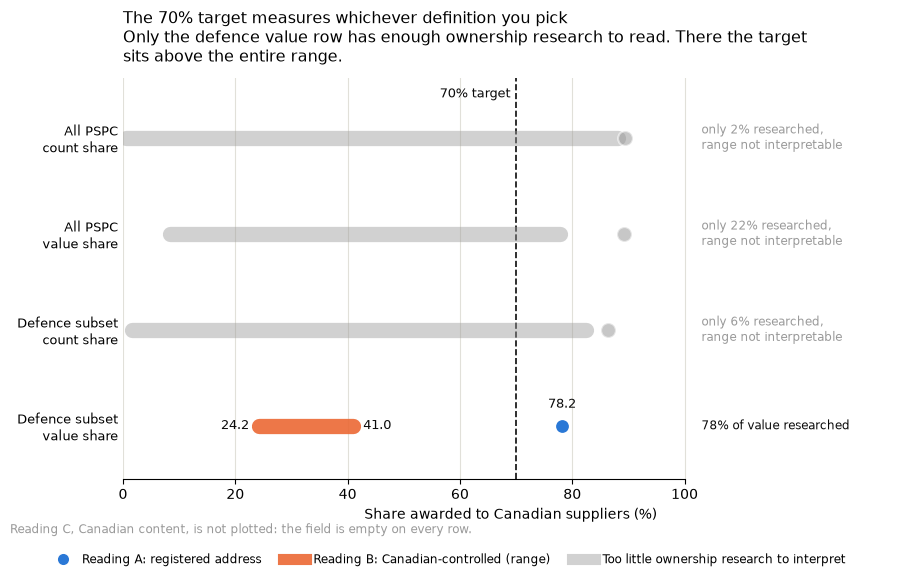

In [57]:
# Chart 1, the deliverable in a picture. Reading A is a point, reading B is a
# range, and the 70% target is a line through both.
# Rows whose ownership research is too thin to interpret are drawn in grey with
# the reason printed beside them, rather than left out. Dropping them would hide
# that three of the four cuts cannot answer the question, which is itself worth
# knowing. Numbers are printed only on the row that can be read, so the eye goes
# there. Blue and orange because they stay separable under colour blindness
import matplotlib.pyplot as plt

MIN_COVERAGE = 50
BLUE, ORANGE, MUTED, GRID, INK = "#2a78d6", "#eb6834", "#9a9a9a", "#e1e0d9", "#0b0b0b"

sens = con.sql("SELECT * FROM mart_sensitivity ORDER BY scope, measure").df().iloc[::-1].reset_index(drop=True)
labels = [("Defence subset" if s == "dnd_end_user" else "All PSPC") + f"\n{m} share"
          for s, m in zip(sens["scope"], sens["measure"])]
y = list(range(len(sens)))

fig, ax = plt.subplots(figsize=(10, 5.2))

for i in y:
    r = sens.iloc[i]
    ok = r["control_coverage_pct"] >= MIN_COVERAGE
    ax.hlines(i, r["reading_b_lower"], r["reading_b_upper"], color=ORANGE if ok else MUTED,
              linewidth=11, alpha=0.9 if ok else 0.45, capstyle="round", zorder=2)
    ax.scatter(r["reading_a"], i, s=115, zorder=4, color=BLUE if ok else MUTED,
               alpha=1.0 if ok else 0.55, edgecolor="white", linewidth=1.5)
    note = (f'{r["control_coverage_pct"]:.0f}% of value researched' if ok
            else f'only {r["control_coverage_pct"]:.0f}% researched,\nrange not interpretable')
    ax.annotate(note, xy=(103, i), va="center", fontsize=8.5, color=INK if ok else MUTED)
    if ok:
        for val, dx, ha in ((r["reading_b_lower"], -7, "right"), (r["reading_b_upper"], 7, "left")):
            ax.annotate(f"{val:.1f}", xy=(val, i), xytext=(dx, 0), textcoords="offset points",
                        ha=ha, va="center", fontsize=9, color=INK)
        ax.annotate(f'{r["reading_a"]:.1f}', xy=(r["reading_a"], i), xytext=(0, 13),
                    textcoords="offset points", ha="center", fontsize=9, color=INK)

ax.axvline(70, color=INK, linestyle="--", linewidth=1.2, zorder=1)
ax.annotate("70% target", xy=(69, len(sens) - 0.58), fontsize=9, color=INK, ha="right")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xlim(0, 138)
ax.set_ylim(-0.55, len(sens) - 0.38)
ax.set_xlabel("Share awarded to Canadian suppliers (%)", fontsize=10)
ax.set_title("The 70% target measures whichever definition you pick\n"
             "Only the defence value row has enough ownership research to read. There the target\n"
             "sits above the entire range.", fontsize=11.5, loc="left", pad=12)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_bounds(0, 100)
ax.tick_params(axis="y", length=0)

ax.legend(handles=[
    plt.Line2D([], [], marker="o", linestyle="", markersize=9, color=BLUE,
               markeredgecolor="white", label="Reading A: registered address"),
    plt.Line2D([], [], linewidth=8, color=ORANGE, alpha=0.9,
               label="Reading B: Canadian-controlled (range)"),
    plt.Line2D([], [], linewidth=8, color=MUTED, alpha=0.45,
               label="Too little ownership research to interpret"),
], loc="upper center", bbox_to_anchor=(0.42, -0.16), ncol=3, fontsize=8.5,
   frameon=False, handletextpad=0.6, columnspacing=1.8)

fig.text(0.012, 0.005, "Reading C, Canadian content, is not plotted: the field is empty on every row.",
         fontsize=8.5, color=MUTED)

plt.savefig("definition_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

In [58]:
# Keyword search on the free-text fields, kept because it fails. If segments
# could be defined by searching words, that is what I would have done, and
# this is the evidence that they cannot be.
# Both text fields get searched, not just the description. Claiming a search
# found nothing is only worth anything if it looked everywhere the text lives
con.sql("""
    WITH t AS (SELECT COALESCE(title_en, '') || ' ' || COALESCE(description_en, '') AS txt FROM stg_contract_history)
    SELECT 'carbon fib' AS term, COUNT(*) FILTER (WHERE txt ILIKE '%carbon fib%') AS rows FROM t
    UNION ALL SELECT 'composite',             COUNT(*) FILTER (WHERE txt ILIKE '%composite%') FROM t
    UNION ALL SELECT 'aerospace or aircraft', COUNT(*) FILTER (WHERE txt ILIKE '%aerospace%' OR txt ILIKE '%aircraft%') FROM t
    UNION ALL SELECT 'uav, drone, rpas, uncrewed, unmanned',
        COUNT(*) FILTER (WHERE txt ILIKE '%uav%' OR txt ILIKE '%drone%' OR txt ILIKE '%rpas%'
                            OR txt ILIKE '%uncrewed%' OR txt ILIKE '%unmanned%') FROM t
""")

┌──────────────────────────────────────┬───────┐
│                 term                 │ rows  │
│               varchar                │ int64 │
├──────────────────────────────────────┼───────┤
│ carbon fib                           │     0 │
│ composite                            │    20 │
│ aerospace or aircraft                │   252 │
│ uav, drone, rpas, uncrewed, unmanned │    75 │
└──────────────────────────────────────┴───────┘

In [59]:
# The UNSPSC field holds more than one code per row, starred and newline
# separated, up to 289 characters of them. Taking substr(code, 1, 4) off the
# raw string returns an asterisk and three digits, which is not a UNSPSC
# family and silently ignores every code after the first.
# This macro strips the stars, splits on the newline and returns a real list.
# ltrim rather than a regex so there is no escaping to get wrong
con.execute("""
    CREATE OR REPLACE MACRO unspsc_codes(s) AS
      list_filter(list_transform(string_split(s, chr(10)), c -> ltrim(TRIM(c), '*')), c -> c <> '')
""")

assert_rule("A22", "NOTE", "contract carries more than one UNSPSC code", "measure",
    """SELECT reference_number, unspsc_code, len(unspsc_codes(unspsc_code)) AS n_codes
       FROM stg_contract_history WHERE len(unspsc_codes(unspsc_code)) > 1
       ORDER BY n_codes DESC""",
    "first code taken as primary, share of value affected reported in the memo")

A22 NOTE: 6866 rows (31.37%), expected measure


┌──────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│ reference_number │                                                                                                                                                          unspsc_code                                                                                                                                                          │ n_codes │
│     varchar      │                                                                                                                                                            varchar                                                                                                                   

In [60]:
# How much of the defence value this actually costs. Segmenting on the first
# code only is a real approximation, so it gets a number rather than a shrug
con.sql("""
    SELECT CASE WHEN len(unspsc_codes(unspsc_code)) = 1 THEN 'one code'
                ELSE 'more than one code' END AS shape,
           COUNT(*) AS contracts, SUM(contract_value_cad) AS keyed_value,
           ROUND(100.0 * SUM(contract_value_cad) / SUM(SUM(contract_value_cad)) OVER (), 1) AS pct_of_value
    FROM fct_contract
    WHERE is_dnd AND value_flag <> 'negative' AND NULLIF(TRIM(unspsc_code), '') IS NOT NULL
    GROUP BY 1 ORDER BY keyed_value DESC
""")

┌────────────────────┬───────────┬───────────────┬──────────────┐
│       shape        │ contracts │  keyed_value  │ pct_of_value │
│      varchar       │   int64   │ decimal(38,2) │    double    │
├────────────────────┼───────────┼───────────────┼──────────────┤
│ one code           │      1777 │ 9853884892.59 │         90.3 │
│ more than one code │       719 │ 1056050783.75 │          9.7 │
└────────────────────┴───────────┴───────────────┴──────────────┘

In [61]:
# Family grain is a container, not a category. 7818 holds airframe heavy
# maintenance next to heavy truck repair and vessel refits, and 2513 holds
# UAVs next to passenger jets. Tagging at family grain would book truck work
# as aerospace, and would leave uncrewed systems with no way to separate them
# from aircraft at all. Whether that matters is a question about money rather
# than about taxonomy, so measure it before changing anything: every family
# holding more than one class, and how the value splits inside it
con.sql("""
    WITH d AS (
        SELECT unspsc_codes(unspsc_code)[1] AS code,
               ltrim(TRIM(split_part(unspsc_description, chr(10), 1)), '*') AS descr,
               contract_value_cad
        FROM fct_contract
        WHERE is_dnd AND value_flag <> 'negative'
          AND NULLIF(TRIM(unspsc_code), '') IS NOT NULL),
    cls AS (
        SELECT substr(code, 1, 4) AS family, substr(code, 1, 6) AS class_code,
               MIN(descr) AS class_label, COUNT(*) AS contracts,
               SUM(contract_value_cad) AS keyed_value
        FROM d GROUP BY 1, 2),
    fam AS (
        SELECT family, SUM(keyed_value) AS family_value, COUNT(*) AS classes_in_family
        FROM cls GROUP BY 1),
    tot AS (SELECT SUM(keyed_value) AS all_value FROM cls)
    SELECT c.family, c.class_code, c.class_label, c.contracts, c.keyed_value,
           ROUND(100.0 * c.keyed_value / f.family_value, 1) AS pct_of_family,
           ROUND(100.0 * f.family_value / t.all_value, 1)  AS family_pct_of_total
    FROM cls c JOIN fam f USING (family) CROSS JOIN tot t
    WHERE f.classes_in_family > 1 AND f.family_value >= 40000000
    ORDER BY f.family_value DESC, c.keyed_value DESC
""").df().to_string()

'    family class_code                                                                        class_label  contracts   keyed_value  pct_of_family  family_pct_of_total\n0     7818     781819                               Rotary wing aircraft maintenance and repair services          1  2.283021e+09           63.0                 33.2\n1     7818     781818                             Aircraft fixed wing airframe heavy maintenance service         11  1.327316e+09           36.6                 33.2\n2     7818     781815                                  Automotive and light truck maintenance and repair         34  8.501853e+06            0.2                 33.2\n3     7818     781820                             Water transport vessel maintenance and repair services          2  2.314513e+06            0.1                 33.2\n4     7818     781816                                                           Panel and paint services          3  8.623125e+05            0.0                 33.

In [62]:
# Draft the UNSPSC segment crosswalk from the families actually present in
# the defence subset, ranked by value so the tagging effort goes where the
# money is. Label comes from the first description, cleaned the same way.
# A family is a container rather than a category, so families carrying real
# money and holding more than one class get class rows as well, and a class
# tag beats its family tag. Almost every family turned out to be one thing,
# but 2513 keeps drones inside an aircraft family and tagging at family grain
# would hide the whole uncrewed capability. How far down to go is measured
# the same way the supplier scope is, by running share rather than a number
# I picked. Untagged rows fall through to other, so the review only has to
# reach as far as the money does. Merges rather than overwrites, same as the
# other two crosswalks
con.execute("""
    CREATE OR REPLACE TABLE unspsc_segment_draft AS
    WITH d AS (
        SELECT unspsc_codes(unspsc_code)[1] AS code,
               ltrim(TRIM(split_part(unspsc_description, chr(10), 1)), '*') AS descr,
               contract_value_cad
        FROM fct_contract
        WHERE is_dnd AND value_flag <> 'negative'
          AND NULLIF(TRIM(unspsc_code), '') IS NOT NULL),
    fam AS (
        SELECT substr(code, 1, 4) AS unspsc_prefix, 'family' AS prefix_level,
               MIN(descr) AS label, COUNT(*) AS contracts,
               SUM(contract_value_cad) AS keyed_value
        FROM d GROUP BY 1, 2),
    cls AS (
        SELECT substr(code, 1, 6) AS unspsc_prefix, 'class' AS prefix_level,
               MIN(descr) AS label, COUNT(*) AS contracts,
               SUM(contract_value_cad) AS keyed_value
        FROM d GROUP BY 1, 2),
    fam_rank AS (
        SELECT substr(unspsc_prefix, 1, 4) AS family, COUNT(*) AS classes_in_family,
               ROW_NUMBER() OVER (ORDER BY SUM(keyed_value) DESC) AS rank,
               100.0 * SUM(SUM(keyed_value)) OVER (ORDER BY SUM(keyed_value) DESC
                     ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
                   / SUM(SUM(keyed_value)) OVER () AS running_share_pct
        FROM cls GROUP BY 1),
    keep AS (
        SELECT family FROM fam_rank
        WHERE classes_in_family > 1
          AND rank <= (SELECT MIN(rank) FROM fam_rank WHERE running_share_pct >= 90))
    SELECT * FROM fam
    UNION ALL
    SELECT c.* FROM cls c JOIN keep k ON substr(c.unspsc_prefix, 1, 4) = k.family
""")

seg_path = Path("crosswalks/unspsc_segment_crosswalk.csv")
if seg_path.exists():
    con.execute("CREATE OR REPLACE TABLE unspsc_segment_prior AS SELECT * FROM read_csv('crosswalks/unspsc_segment_crosswalk.csv', header = true, all_varchar = true)")
    segment_sql = """
        SELECT d.unspsc_prefix, d.prefix_level, d.label, d.contracts, d.keyed_value,
               COALESCE(p.segment, '')    AS segment,
               COALESCE(p.source_url, '') AS source_url,
               COALESCE(p.note, '')       AS note
        FROM unspsc_segment_draft d LEFT JOIN unspsc_segment_prior p USING (unspsc_prefix)"""
else:
    segment_sql = """
        SELECT unspsc_prefix, prefix_level, label, contracts, keyed_value,
               '' AS segment, '' AS source_url, '' AS note
        FROM unspsc_segment_draft"""

con.execute(f"COPY ({segment_sql} ORDER BY prefix_level, keyed_value DESC) TO 'crosswalks/unspsc_segment_crosswalk.csv' (HEADER)")

con.sql(f"SELECT prefix_level, COUNT(*) AS rows, SUM(keyed_value) AS keyed_value FROM ({segment_sql}) GROUP BY 1")

┌──────────────┬───────┬────────────────┐
│ prefix_level │ rows  │  keyed_value   │
│   varchar    │ int64 │ decimal(38,2)  │
├──────────────┼───────┼────────────────┤
│ class        │   112 │  8780203905.19 │
│ family       │   238 │ 10909935676.34 │
└──────────────┴───────┴────────────────┘

In [63]:
# UNSPSC dimension, keyed on the raw field rather than on a cleaned code,
# because the fact table carries the raw string and the join has to match
# what is actually in it. Family and class come off the first code through
# the macro, since taking substr of the raw string returns an asterisk and
# three digits instead of a family. Segment resolves class first and family
# second, so a class tag beats the family it sits in, which is the only way
# the uncrewed capability stays visible instead of being absorbed into
# aircraft. segment_source records which of the two decided each row, so the
# crosswalk can be audited without re-running the join by hand
con.execute("CREATE OR REPLACE TABLE unspsc_segment_crosswalk AS SELECT * FROM read_csv('crosswalks/unspsc_segment_crosswalk.csv', header = true, all_varchar = true)")
con.execute("""
    CREATE OR REPLACE TABLE dim_unspsc AS
    WITH codes AS (
        SELECT DISTINCT unspsc_code,
               unspsc_codes(unspsc_code)[1]   AS primary_code,
               len(unspsc_codes(unspsc_code)) AS codes_on_contract
        FROM stg_contract_history
        WHERE NULLIF(TRIM(unspsc_code), '') IS NOT NULL)
    SELECT c.unspsc_code, c.primary_code, c.codes_on_contract,
           substr(c.primary_code, 1, 4) AS family,
           substr(c.primary_code, 1, 6) AS class_code,
           COALESCE(NULLIF(x.segment, ''), NULLIF(f.segment, ''), 'other') AS segment,
           COALESCE(NULLIF(x.segment, ''), NULLIF(f.segment, ''), 'other')
               IN ('aerospace', 'uncrewed_autonomous', 'specialized_manufacturing') AS is_pfaff_relevant,
           CASE WHEN NULLIF(x.segment, '') IS NOT NULL THEN 'class'
                WHEN NULLIF(f.segment, '') IS NOT NULL THEN 'family'
                ELSE 'default' END AS segment_source
    FROM codes c
    LEFT JOIN unspsc_segment_crosswalk x
           ON x.prefix_level = 'class'  AND x.unspsc_prefix = substr(c.primary_code, 1, 6)
    LEFT JOIN unspsc_segment_crosswalk f
           ON f.prefix_level = 'family' AND f.unspsc_prefix = substr(c.primary_code, 1, 4)
""")

con.sql("""
    SELECT segment, segment_source, COUNT(*) AS codes
    FROM dim_unspsc GROUP BY 1, 2 ORDER BY segment, segment_source
""")

┌───────────────────────────┬────────────────┬───────┐
│          segment          │ segment_source │ codes │
│          varchar          │    varchar     │ int64 │
├───────────────────────────┼────────────────┼───────┤
│ aerospace                 │ family         │    37 │
│ other                     │ class          │    34 │
│ other                     │ default        │  1966 │
│ other                     │ family         │   653 │
│ specialized_manufacturing │ class          │     1 │
│ specialized_manufacturing │ family         │    59 │
│ uncrewed_autonomous       │ class          │     4 │
└───────────────────────────┴────────────────┴───────┘

In [64]:
# Segments and spend analysis. Concentration is measured twice, once at the
# legal entity the contract was actually awarded to and once at the ultimate
# parent standing behind it, because those are different questions and the
# distance between them is the finding rather than a technicality. Seven name
# keys spell General Dynamics, and at entity grain each one reads as a
# moderate supplier. HHI is the sum of squared value shares times 10,000,
# built in a subquery because a window will not nest inside an aggregate.
# Control coverage travels with every row so reading B is only read where
# enough of that segment was actually researched to mean anything
con.execute("""
    CREATE OR REPLACE TABLE mart_segments AS
    WITH base AS (
        SELECT f.reference_number, f.contract_value_cad, f.country_iso2, f.supplier_name_key,
               COALESCE(u.segment, 'unclassified') AS segment,
               d.control_class, d.ultimate_parent
        FROM fct_contract f
        LEFT JOIN dim_unspsc u ON f.unspsc_code = u.unspsc_code
        JOIN dim_supplier d USING (supplier_name_key)
        WHERE f.is_dnd AND f.value_flag <> 'negative'),
    grains AS (
        SELECT 'legal_entity' AS grain, segment, supplier_name_key AS grp,
               SUM(contract_value_cad) AS v
        FROM base WHERE contract_value_cad > 0 GROUP BY 1, 2, 3
        UNION ALL
        SELECT 'ultimate_parent', segment, ultimate_parent, SUM(contract_value_cad)
        FROM base WHERE contract_value_cad > 0 GROUP BY 1, 2, 3),
    shares AS (
        SELECT grain, segment, v,
               100.0 * v / SUM(v) OVER (PARTITION BY grain, segment) AS share_pct,
               ROW_NUMBER() OVER (PARTITION BY grain, segment ORDER BY v DESC) AS rk
        FROM grains),
    conc AS (
        SELECT grain, segment, COUNT(*) AS suppliers,
               ROUND(SUM(share_pct * share_pct), 0) AS hhi,
               ROUND(MAX(share_pct), 1) AS top1_share_pct,
               ROUND(SUM(share_pct) FILTER (WHERE rk <= 3), 1) AS top3_share_pct
        FROM shares GROUP BY 1, 2)
    SELECT b.segment, COUNT(*) AS contracts, SUM(b.contract_value_cad) AS keyed_value,
           ROUND(100.0 * SUM(b.contract_value_cad) FILTER (WHERE b.country_iso2 = 'CA')
                 / SUM(b.contract_value_cad), 1) AS reading_a_pct,
           ROUND(100.0 * SUM(b.contract_value_cad) FILTER (WHERE b.country_iso2 = 'CA'
                 AND b.control_class = 'canadian_controlled')
                 / SUM(b.contract_value_cad), 1) AS reading_b_lower_pct,
           ROUND(100.0 * SUM(b.contract_value_cad) FILTER (WHERE b.country_iso2 = 'CA'
                 AND b.control_class IN ('canadian_controlled', 'unresolved'))
                 / SUM(b.contract_value_cad), 1) AS reading_b_upper_pct,
           ROUND(100.0 * SUM(b.contract_value_cad) FILTER (WHERE b.country_iso2 = 'CA'
                 AND b.control_class <> 'unresolved')
                 / NULLIF(SUM(b.contract_value_cad) FILTER (WHERE b.country_iso2 = 'CA'), 0), 1)
                 AS control_coverage_pct,
           e.suppliers AS legal_entities, e.hhi AS hhi_entity,
           e.top1_share_pct AS top1_entity, e.top3_share_pct AS top3_entity,
           p.suppliers AS parents, p.hhi AS hhi_parent,
           p.top1_share_pct AS top1_parent, p.top3_share_pct AS top3_parent,
           p.hhi - e.hhi AS hhi_gap
    FROM base b
    JOIN conc e ON e.segment = b.segment AND e.grain = 'legal_entity'
    JOIN conc p ON p.segment = b.segment AND p.grain = 'ultimate_parent'
    GROUP BY b.segment, e.suppliers, e.hhi, e.top1_share_pct, e.top3_share_pct,
             p.suppliers, p.hhi, p.top1_share_pct, p.top3_share_pct
    ORDER BY keyed_value DESC
""")

# The coverage rule sits in the table rather than in the memo: below 50%
# coverage reading B is not a range, it is an artefact of how little was
# researched
con.execute("""
    ALTER TABLE mart_segments ADD COLUMN reading_b_interpretable BOOLEAN
""")
con.execute("""
    UPDATE mart_segments SET reading_b_interpretable = control_coverage_pct >= 50
""")

con.sql("""
    SELECT segment, contracts, keyed_value, reading_a_pct, reading_b_lower_pct,
           reading_b_upper_pct, control_coverage_pct, reading_b_interpretable
    FROM mart_segments ORDER BY keyed_value DESC
""").df().to_string()

'                     segment  contracts   keyed_value  reading_a_pct  reading_b_lower_pct  reading_b_upper_pct  control_coverage_pct  reading_b_interpretable\n0               unclassified        260  8.968530e+09           64.4                 25.9                 28.9                  95.3                     True\n1                      other       2347  4.773212e+09           96.1                 11.9                 74.6                  34.8                    False\n2                  aerospace         49  4.308220e+09           97.5                 43.6                 44.5                  99.1                     True\n3  specialized_manufacturing         80  1.826365e+09           53.1                  1.6                  4.6                  94.3                     True\n4        uncrewed_autonomous         20  2.138083e+06           35.3                  0.0                 35.3                   0.0                    False'

In [65]:
# The same spend counted two ways. At legal-entity grain a contract belongs
# to whoever signed it, which is how the award data reads and how a naive
# concentration measure would report it. At parent grain the subsidiaries
# collapse into whoever owns them. Nothing about the money changes between
# these two tables, only the question being asked, and hhi_gap is how much
# the answer moves. Reported for the segments worth reporting, since a
# concentration number on a segment holding 20 contracts is arithmetic
# rather than evidence
con.sql("""
    SELECT segment, contracts, keyed_value,
           legal_entities, hhi_entity, top1_entity, top3_entity,
           parents, hhi_parent, top1_parent, top3_parent, hhi_gap
    FROM mart_segments ORDER BY keyed_value DESC
""").df().to_string()

'                     segment  contracts   keyed_value  legal_entities  hhi_entity  top1_entity  top3_entity  parents  hhi_parent  top1_parent  top3_parent  hhi_gap\n0               unclassified        260  8.968530e+09              78      1051.0         19.8         49.1       78      1051.0         19.8         49.1      0.0\n1                      other       2347  4.773212e+09            1169       219.0         10.8         19.8     1169       219.0         10.8         19.8      0.0\n2                  aerospace         49  4.308220e+09              41      3864.0         53.0         96.6       41      3864.0         53.0         96.6      0.0\n3  specialized_manufacturing         80  1.826365e+09              36      2138.0         37.9         71.3       34      2446.0         37.9         79.9    308.0\n4        uncrewed_autonomous         20  2.138083e+06              18      4921.0         64.7        100.0       18      4921.0         64.7        100.0      0.0'

In [66]:
# Top Canadian-address defence suppliers, ranked twice. The first table is
# what the award data says: one row per legal entity, which is the grain a
# contract is actually signed at. The second groups by who owns them.
# General Dynamics never appears as a single supplier in the first table
# because its awards arrived under four separate name keys, and only the
# second shows what it is worth together. name_keys records how many entities
# each parent absorbed, so a reader can see which rows moved and which did
# not, and can tell consolidation apart from a supplier that was already
# whole. Both are kept because Power BI needs the entity grain and the memo
# needs the parent grain
con.execute("""
    CREATE OR REPLACE TABLE mart_top_suppliers AS
    SELECT ROW_NUMBER() OVER (ORDER BY SUM(f.contract_value_cad) DESC) AS rank,
           f.supplier_name_key, d.example_legal_name, d.control_class, d.ultimate_parent,
           COUNT(*) AS contracts, SUM(f.contract_value_cad) AS keyed_value
    FROM fct_contract f JOIN dim_supplier d USING (supplier_name_key)
    WHERE f.is_dnd AND f.country_iso2 = 'CA' AND f.contract_value_cad > 0
    GROUP BY f.supplier_name_key, d.example_legal_name, d.control_class, d.ultimate_parent
    ORDER BY keyed_value DESC LIMIT 15
""")
con.execute("""
    CREATE OR REPLACE TABLE mart_top_parents AS
    SELECT ROW_NUMBER() OVER (ORDER BY SUM(f.contract_value_cad) DESC) AS rank,
           d.ultimate_parent, MIN(d.control_class) AS control_class,
           COUNT(DISTINCT f.supplier_name_key) AS name_keys,
           COUNT(*) AS contracts, SUM(f.contract_value_cad) AS keyed_value
    FROM fct_contract f JOIN dim_supplier d USING (supplier_name_key)
    WHERE f.is_dnd AND f.country_iso2 = 'CA' AND f.contract_value_cad > 0
    GROUP BY d.ultimate_parent
    ORDER BY keyed_value DESC LIMIT 15
""")

print(con.sql("SELECT rank, example_legal_name, control_class, contracts, keyed_value FROM mart_top_suppliers ORDER BY rank").df().to_string())
print()
print(con.sql("SELECT rank, ultimate_parent, control_class, name_keys, contracts, keyed_value FROM mart_top_parents ORDER BY rank").df().to_string())

    rank                                             example_legal_name                  control_class  contracts   keyed_value
0      1                                    Bell Textron Canada Limited  foreign_controlled_subsidiary          1  2.283021e+09
1      2                               Allied Wings Limited Partnership            canadian_controlled          1  1.772435e+09
2      3                                    LOCKHEED MARTIN CANADA INC.  foreign_controlled_subsidiary          6  1.311935e+09
3      4                                          Cascade Aerospace Inc            canadian_controlled          1  1.245164e+09
4      5                             Victoria Shipyards Company Limited  foreign_controlled_subsidiary          1  7.860612e+08
5      6                                              WEIR CANADA, INC.  foreign_controlled_subsidiary          1  6.438600e+08
6      7                                                Bombardier Inc.            canadian_controlled  

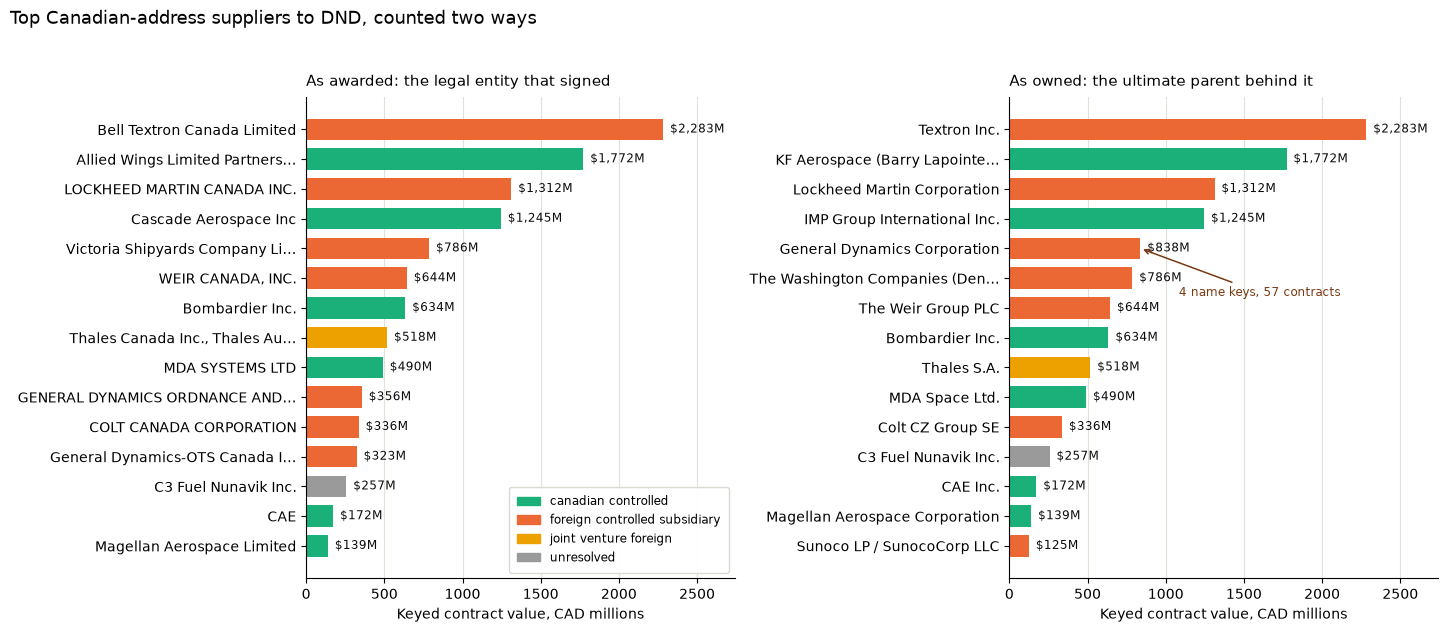

In [67]:
# Chart 2, the same suppliers drawn twice. The left panel is the award data
# as published, one bar per legal entity. The right panel groups those
# entities by who owns them. Colour carries control class in both, so what
# the reader is comparing is the labels and the ranking rather than the
# palette. Bell Textron sits at the top of both because nothing about it
# consolidates. General Dynamics is the row that moves, and the callout finds
# whichever parent absorbed the most name keys instead of naming a company
# that might not be there after a re-pull. Both panels are pinned to one x
# scale, since letting the right one rescale itself would hide the very
# comparison the chart exists to make
ent = con.sql("SELECT example_legal_name AS name, control_class, keyed_value FROM mart_top_suppliers ORDER BY keyed_value").df()
par = con.sql("SELECT ultimate_parent AS name, control_class, keyed_value, name_keys, contracts FROM mart_top_parents ORDER BY keyed_value").df()

palette = {"canadian_controlled": "#1baf7a", "foreign_controlled_subsidiary": "#eb6834",
           "joint_venture_foreign": "#eda100", "unresolved": "#9a9a9a"}

# legal names run past 60 characters and would take half the plot width, so
# the axis gets a shortened form. the tables above keep them whole
def short(s, n=30):
    s = " ".join(str(s).split())
    return s if len(s) <= n else s[:n - 1].rstrip(" ,-") + "…"

xmax = max(ent["keyed_value"].max(), par["keyed_value"].max()) / 1e6 * 1.20

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.4))
for ax, d, title in ((axes[0], ent, "As awarded: the legal entity that signed"),
                     (axes[1], par, "As owned: the ultimate parent behind it")):
    ax.barh([short(x) for x in d["name"]], d["keyed_value"] / 1e6,
            color=[palette[c] for c in d["control_class"]], height=0.72)
    for i, v in enumerate(d["keyed_value"] / 1e6):
        ax.annotate(f"${v:,.0f}M", xy=(v, i), xytext=(5, 0), textcoords="offset points",
                    va="center", fontsize=8.5, color="#0b0b0b")
    ax.set_xlim(0, xmax)
    ax.set_xlabel("Keyed contract value, CAD millions")
    ax.set_title(title, loc="left", fontsize=11, pad=8)
    ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

merged = par[par["name_keys"] > 1]
if len(merged):
    r = merged["name_keys"].idxmax()
    v = par.loc[r, "keyed_value"] / 1e6
    axes[1].annotate(f"{par.loc[r, 'name_keys']} name keys, {par.loc[r, 'contracts']} contracts",
                     xy=(v, r), xytext=(v + xmax * 0.09, r - 1.6), fontsize=8.5, color="#7a3a12",
                     arrowprops=dict(arrowstyle="->", color="#7a3a12", lw=1.1))

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
leg = axes[0].legend(handles, [k.replace("_", " ") for k in palette],
                     loc="lower right", fontsize=8.5, framealpha=0.96, borderpad=0.7)
leg.get_frame().set_edgecolor("#d9d8d1")
fig.suptitle("Top Canadian-address suppliers to DND, counted two ways", x=0.005, ha="left", fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.955])
plt.savefig("top_suppliers_by_control.png", dpi=150, bbox_inches="tight")
plt.show()

In [68]:
# The amendment-grain fact, and the clearest place to show the grain defect.
# Lagging the contract total cannot work, because the total is repeated
# unchanged on every amendment row of a contract, so its delta is zero every
# time and tells you nothing about what the amendment did. contractAmount is
# the column that actually moves at this grain. Both are lagged and kept, so
# the zero column sits next to the one that varies and the reader can see
# why summing the total across these rows doubles the file.
# The blank end user is built with the same TRIM test dim_end_user uses,
# since blanks here are empty strings rather than nulls and a COALESCE would
# match nothing and quietly drop those rows on export.
# The non-numeric amendment codes sort first, so they act as the baseline for
# their contract rather than as a later amendment to it.
# amendment_type and amendment_date are the publisher's own account of what
# each row is and when it happened, which the award date cannot give since it
# is the original award repeated on every row.
# The deltas are not summed. contractAmount turns out to mean different
# things on different contracts, so a total of these changes would be a
# confident number with nothing behind it. The per-row delta is still true
# row by row and is kept for that
con.execute("""
    CREATE OR REPLACE TABLE fct_contract_amendment AS
    SELECT s.row_id, s.reference_number, s.amendment_number, s.amendment_sort_key, s.award_date,
           s.contract_value_cad, s.contract_amount_cad,
           s.amendment_type, s.amendment_date, s.instrument_type,
           s.supplier_name_key, s.unspsc_code,
           CASE WHEN NULLIF(TRIM(s.end_user_entity), '') IS NULL THEN '(blank)'
                ELSE s.end_user_entity END AS end_user_name,
           cc.country_iso2,
           s.contract_amount_cad - LAG(s.contract_amount_cad) OVER w AS amount_delta_vs_prior,
           s.contract_value_cad  - LAG(s.contract_value_cad)  OVER w AS total_delta_vs_prior
    FROM stg_contract_history s JOIN v_contract_country cc USING (row_id)
    WINDOW w AS (PARTITION BY s.reference_number ORDER BY s.amendment_sort_key, s.row_id)
""")

con.sql("""
    SELECT COUNT(*) FILTER (WHERE amount_delta_vs_prior IS NOT NULL) AS amendment_rows,
           COUNT(*) FILTER (WHERE total_delta_vs_prior <> 0)  AS rows_where_total_moved,
           COUNT(*) FILTER (WHERE amount_delta_vs_prior <> 0) AS rows_where_amount_moved,
           COUNT(DISTINCT reference_number) FILTER (WHERE amount_delta_vs_prior <> 0) AS contracts_with_amount_change,
           COUNT(*) FILTER (WHERE amount_delta_vs_prior > 0) AS amendments_up,
           COUNT(*) FILTER (WHERE amount_delta_vs_prior < 0) AS amendments_down,
    FROM fct_contract_amendment
""")

┌────────────────┬────────────────────────┬─────────────────────────┬──────────────────────────────┬───────────────┬─────────────────┐
│ amendment_rows │ rows_where_total_moved │ rows_where_amount_moved │ contracts_with_amount_change │ amendments_up │ amendments_down │
│     int64      │         int64          │          int64          │            int64             │     int64     │      int64      │
├────────────────┼────────────────────────┼─────────────────────────┼──────────────────────────────┼───────────────┼─────────────────┤
│           5498 │                      0 │                    3957 │                         2228 │          1317 │            2640 │
└────────────────┴────────────────────────┴─────────────────────────┴──────────────────────────────┴───────────────┴─────────────────┘

In [69]:
# Before reading anything into the amendment deltas, work out what
# contractAmount actually means, because the two possibilities point in
# opposite directions. If the amounts sum to the contract total then each row
# is that amendment's own increment and a negative delta only says this
# amendment was smaller than the last one. If instead the largest amount
# equals the total then the column is a restatement and a negative delta
# really is value coming off the contract. The same arithmetic cannot mean
# both, and the memo would be making a claim either way, so measure it.
# The null count matters too: the LAG chain breaks wherever either side is
# missing, which is why the delta covers fewer rows than there are amendments
con.sql("""
    WITH c AS (
        SELECT reference_number,
               COUNT(*)                     AS rows,
               COUNT(contract_amount_cad)   AS rows_with_amount,
               MAX(contract_value_cad)      AS total,
               SUM(contract_amount_cad)     AS sum_amounts,
               MAX(contract_amount_cad)     AS max_amount
        FROM stg_contract_history GROUP BY 1)
    SELECT COUNT(*) AS contracts,
           COUNT(*) FILTER (WHERE rows > 1) AS amended_contracts,
           COUNT(*) FILTER (WHERE rows > 1 AND abs(sum_amounts - total) < 0.01) AS sum_of_amounts_equals_total,
           COUNT(*) FILTER (WHERE rows > 1 AND abs(max_amount - total) < 0.01)  AS largest_amount_equals_total,
           COUNT(*) FILTER (WHERE rows_with_amount < rows)  AS contracts_missing_some_amount,
           COUNT(*) FILTER (WHERE rows_with_amount = 0)     AS contracts_missing_every_amount
    FROM c
""")

┌───────────┬───────────────────┬─────────────────────────────┬─────────────────────────────┬───────────────────────────────┬────────────────────────────────┐
│ contracts │ amended_contracts │ sum_of_amounts_equals_total │ largest_amount_equals_total │ contracts_missing_some_amount │ contracts_missing_every_amount │
│   int64   │       int64       │            int64            │            int64            │             int64             │             int64              │
├───────────┼───────────────────┼─────────────────────────────┼─────────────────────────────┼───────────────────────────────┼────────────────────────────────┤
│     13296 │              4314 │                        2926 │                        2054 │                          2245 │                            595 │
└───────────┴───────────────────┴─────────────────────────────┴─────────────────────────────┴───────────────────────────────┴────────────────────────────────┘

In [70]:
# The previous cell said neither reading explains the file, so partition the
# contracts instead of counting two overlapping tests. Nulls are excluded
# rather than tolerated here, because a contract missing an amount can fail
# both tests for a reason that has nothing to do with what the column means.
# What comes back decides whether any sum of amendment changes is reportable
# at all, and a split result is itself the answer: a column that is an
# increment on some contracts and a restatement on others has no single
# meaning to report
con.sql("""
    WITH c AS (
        SELECT reference_number, COUNT(*) AS rows, COUNT(contract_amount_cad) AS rows_with_amount,
               MAX(contract_value_cad) AS total, SUM(contract_amount_cad) AS sum_amounts,
               MAX(contract_amount_cad) AS max_amount
        FROM stg_contract_history GROUP BY 1),
    clean AS (
        SELECT *, abs(sum_amounts - total) < 0.01 AS sum_matches,
                  abs(max_amount - total) < 0.01 AS max_matches
        FROM c
        WHERE rows > 1 AND rows_with_amount = rows AND total IS NOT NULL AND total <> 0)
    SELECT CASE WHEN sum_matches AND max_matches THEN 'both, one row carries the whole total'
                WHEN sum_matches THEN 'increment per amendment'
                WHEN max_matches THEN 'restatement of the contract'
                ELSE 'neither' END AS reading,
           COUNT(*) AS contracts,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_of_testable,
           SUM(total) AS total_value
    FROM clean GROUP BY 1 ORDER BY contracts DESC
""")

┌───────────────────────────────────────┬───────────┬─────────────────┬────────────────┐
│                reading                │ contracts │ pct_of_testable │  total_value   │
│                varchar                │   int64   │     double      │ decimal(38,2)  │
├───────────────────────────────────────┼───────────┼─────────────────┼────────────────┤
│ neither                               │       866 │            39.9 │ 11972474750.14 │
│ increment per amendment               │       855 │            39.4 │  4067088870.31 │
│ both, one row carries the whole total │       353 │            16.3 │   997956403.23 │
│ restatement of the contract           │        94 │             4.3 │    88947688.90 │
└───────────────────────────────────────┴───────────┴─────────────────┴────────────────┘

In [71]:
# A24: the file calls every row a contract, and the publisher's instrument
# type says otherwise. Standing offers and supply arrangements are offers to
# supply at a price, not awards of money, and they sit here at the same grain
# as contracts with a total that is usually zero. That is where A5's quarter
# of zero-value rows comes from. Recorded as a rule so the share is on the
# record, and summarised at contract grain because that is the grain the
# question is asked at. Whether an offer counts as an acquisition is a
# definitional call, so the cell after A26 measures what excluding them does
# rather than deciding it here
assert_rule("A24", "WARN", "instrument_type is a standing offer or supply arrangement", "measure",
    """SELECT row_id, reference_number, instrument_type, contract_value_cad
       FROM stg_contract_history WHERE instrument_type IN ('Standing Offer', 'Supply Arrangement')""",
    "kept, flagged, effect on the readings reported beside the sensitivity table")

con.sql("""
    SELECT COALESCE(instrument_type, '(blank)') AS instrument_type, COUNT(*) AS contracts,
           COUNT(*) FILTER (WHERE value_flag = 'zero') AS zero_value,
           ROUND(100.0 * COUNT(*) FILTER (WHERE value_flag = 'zero') / COUNT(*), 1) AS pct_zero,
           SUM(contract_value_cad) FILTER (WHERE contract_value_cad > 0) AS keyed_value,
           ROUND(100.0 * SUM(contract_value_cad) FILTER (WHERE contract_value_cad > 0)
                 / SUM(SUM(contract_value_cad) FILTER (WHERE contract_value_cad > 0)) OVER (), 1) AS pct_of_value,
           COUNT(*) FILTER (WHERE is_dnd) AS dnd_contracts,
           SUM(contract_value_cad) FILTER (WHERE is_dnd AND contract_value_cad > 0) AS dnd_keyed_value
    FROM fct_contract GROUP BY 1 ORDER BY keyed_value DESC NULLS LAST
""")

A24 WARN: 6519 rows (29.78%), expected measure


┌───────────────────────────────────┬───────────┬────────────┬──────────┬────────────────┬──────────────┬───────────────┬─────────────────┐
│          instrument_type          │ contracts │ zero_value │ pct_zero │  keyed_value   │ pct_of_value │ dnd_contracts │ dnd_keyed_value │
│              varchar              │   int64   │   int64    │  double  │ decimal(38,2)  │    double    │     int64     │  decimal(38,2)  │
├───────────────────────────────────┼───────────┼────────────┼──────────┼────────────────┼──────────────┼───────────────┼─────────────────┤
│ Contract                          │      6637 │         20 │      0.3 │ 45896203947.98 │         69.2 │          1362 │   8398492431.07 │
│ (blank)                           │       833 │        268 │     32.2 │ 13447166160.79 │         20.3 │           261 │   8968530273.57 │
│ Standing Offer                    │      2252 │       1469 │     65.2 │  2958446470.92 │          4.5 │           777 │   1524779144.45 │
│ Task Authorization

In [72]:
# A25: the publisher's own row type. Original rows sit at amendment 000,
# amendment and termination rows after it, and the untyped rows are the legacy
# population measured at A26. What matters for the amendment analysis is the
# contracts with no original row in the file at all: their total is the
# cumulative value of an award this file never recorded, so the amounts on the
# rows it does hold cannot add up to it by construction. Splitting the reading
# partition above by whether the original row is present shows how much of the
# "neither" group that explains, and how much is left unexplained on
# contracts where every row is there
assert_rule("A25", "NOTE", "contract has no Original row in the file", "measure",
    """SELECT reference_number, COUNT(*) AS rows, MIN(amendment_number) AS first_amendment,
              MAX(contract_value_cad) AS total
       FROM stg_contract_history GROUP BY 1
       HAVING COUNT(*) FILTER (WHERE amendment_type = 'Original') = 0
       ORDER BY total DESC""",
    "kept; explains most of the value the neither reading could not")

print(con.sql("""
    SELECT COALESCE(amendment_type, '(blank)') AS amendment_type,
           CASE WHEN amendment_number = '000' THEN 'row 000' ELSE 'later row' END AS position,
           COUNT(*) AS rows,
           COUNT(*) FILTER (WHERE contract_amount_cad IS NULL) AS amount_null,
           COUNT(*) FILTER (WHERE contract_amount_cad = 0) AS amount_zero
    FROM stg_contract_history GROUP BY 1, 2 ORDER BY 1, 2
""").df().to_string(index=False))
print()
print(con.sql("""
    WITH c AS (
        SELECT reference_number, COUNT(*) AS rows, COUNT(contract_amount_cad) AS rows_with_amount,
               MAX(contract_value_cad) AS total, SUM(contract_amount_cad) AS sum_amounts,
               MAX(contract_amount_cad) AS max_amount,
               COUNT(*) FILTER (WHERE amendment_type = 'Original') > 0 AS has_original
        FROM stg_contract_history GROUP BY 1),
    clean AS (
        SELECT *, abs(sum_amounts - total) < 0.01 AS sum_matches,
                  abs(max_amount - total) < 0.01 AS max_matches
        FROM c WHERE rows > 1 AND rows_with_amount = rows AND total IS NOT NULL AND total <> 0)
    SELECT CASE WHEN sum_matches AND max_matches THEN 'both, one row carries the whole total'
                WHEN sum_matches THEN 'increment per amendment'
                WHEN max_matches THEN 'restatement of the contract'
                ELSE 'neither' END AS reading,
           has_original, COUNT(*) AS contracts, SUM(total) AS total_value,
           ROUND(100.0 * SUM(total) / SUM(SUM(total)) OVER (), 1) AS pct_of_testable_value
    FROM clean GROUP BY 1, 2 ORDER BY 1, 2 DESC
""").df().to_string(index=False))

A25 NOTE: 2686 rows (12.27%), expected measure
amendment_type  position  rows  amount_null  amount_zero
       (blank) later row  1156            2          714
       (blank)   row 000   653            0           22
     Amendment later row  9433         3361         1958
      Original   row 000 10610            0         2897
   Termination later row    38           20            9

                              reading  has_original  contracts  total_value  pct_of_testable_value
both, one row carries the whole total          True        235 4.918133e+08                    2.9
both, one row carries the whole total         False        118 5.061431e+08                    3.0
              increment per amendment          True        682 2.941955e+09                   17.2
              increment per amendment         False        173 1.125134e+09                    6.6
                              neither          True        568 1.572433e+09                    9.2
                

In [73]:
# A26: the rows with no UNSPSC code, no instrument type and no amendment
# type are the same rows, and none of them carries a CanadaBuys CW reference.
# They are records carried over from the procurement system that preceded
# CanadaBuys, kept in this file because their amendments continue. Every
# undated row is one of them, and so is every unclassified defence contract.
# That turns the segment finding around: the share of defence value with no
# code is not a coding gap scattered through the file, it is the old system's
# records, and they are the large, long-running contracts
assert_rule("A26", "WARN", "legacy-format reference_number, not CW-numbered", "measure",
    """SELECT row_id, reference_number, amendment_number, award_date, contract_value_cad,
              NULLIF(TRIM(unspsc_code), '') IS NULL AS unspsc_blank,
              NULLIF(TRIM(instrument_type), '') IS NULL AS instrument_blank
       FROM stg_contract_history WHERE NOT regexp_matches(reference_number, '^CW[0-9]+$')
       ORDER BY contract_value_cad DESC""",
    "kept; reported as the population behind the unclassified segment and the undated rows")

print(con.sql("""
    SELECT NULLIF(TRIM(amendment_type), '') IS NULL  AS type_blank,
           NULLIF(TRIM(instrument_type), '') IS NULL AS instrument_blank,
           NULLIF(TRIM(unspsc_code), '') IS NULL     AS unspsc_blank,
           COUNT(*) AS rows,
           COUNT(*) FILTER (WHERE regexp_matches(reference_number, '^CW[0-9]+$')) AS cw_refs,
           COUNT(*) FILTER (WHERE award_date IS NULL) AS undated
    FROM stg_contract_history GROUP BY 1, 2, 3 ORDER BY rows DESC
""").df().to_string(index=False))
print()
print(con.sql("""
    SELECT CASE WHEN is_cw_reference THEN 'CanadaBuys CW reference' ELSE 'legacy reference' END AS reference_format,
           NULLIF(TRIM(unspsc_code), '') IS NULL AS unspsc_blank,
           COUNT(*) AS contracts, COUNT(*) FILTER (WHERE award_date IS NULL) AS undated,
           SUM(contract_value_cad) AS keyed_value,
           ROUND(100.0 * SUM(contract_value_cad) / SUM(SUM(contract_value_cad)) OVER (), 1) AS pct_of_defence_value
    FROM fct_contract WHERE is_dnd AND value_flag <> 'negative'
    GROUP BY 1, 2 ORDER BY keyed_value DESC
""").df().to_string(index=False))

A26 WARN: 2343 rows (10.70%), expected measure
 type_blank  instrument_blank  unspsc_blank  rows  cw_refs  undated
      False             False         False 20078    19543        0
       True              True          True  1762        0      305
       True             False         False    47        1        0
      False              True         False     3        3        0

       reference_format  unspsc_blank  contracts  undated  keyed_value  pct_of_defence_value
CanadaBuys CW reference         False       2466        0 8.989008e+09                  45.2
       legacy reference          True        260       47 8.968530e+09                  45.1
       legacy reference         False         30        0 1.920928e+09                   9.7


In [74]:
# What excluding the offers does to the readings. The instrument type says
# which rows are offers to supply rather than awards, so the same readings are
# measured with them, without them, and on them alone, for both scopes. It
# goes beside the sensitivity table as a line rather than into it as rows,
# because the offers turn out to sit almost entirely at Canadian addresses and
# to carry a small share of the value, so what they move is the address
# reading by a couple of points. That is worth stating and is not the
# definitional swing the table is about. Coverage travels with each row for
# the same reason it does everywhere else
con.execute("""
    CREATE OR REPLACE TABLE mart_instrument_sensitivity AS
    WITH base AS (
        SELECT f.*, d.control_class,
               COALESCE(f.instrument_type, '') IN ('Standing Offer', 'Supply Arrangement') AS is_offer
        FROM fct_contract f JOIN dim_supplier d USING (supplier_name_key)
        WHERE f.value_flag <> 'negative' AND f.contract_value_cad > 0),
    scoped AS (
        SELECT 'all_pspc' AS scope, 'all instruments' AS instruments, * FROM base
        UNION ALL SELECT 'all_pspc', 'without offers', * FROM base WHERE NOT is_offer
        UNION ALL SELECT 'all_pspc', 'offers only', * FROM base WHERE is_offer
        UNION ALL SELECT 'dnd_end_user', 'all instruments', * FROM base WHERE is_dnd
        UNION ALL SELECT 'dnd_end_user', 'without offers', * FROM base WHERE is_dnd AND NOT is_offer
        UNION ALL SELECT 'dnd_end_user', 'offers only', * FROM base WHERE is_dnd AND is_offer)
    SELECT scope, instruments, COUNT(*) AS contracts, SUM(contract_value_cad) AS keyed_value,
           ROUND(100.0 * SUM(contract_value_cad) FILTER (WHERE country_iso2 = 'CA')
                 / SUM(contract_value_cad), 2) AS reading_a,
           ROUND(100.0 * SUM(contract_value_cad) FILTER (WHERE country_iso2 = 'CA' AND control_class = 'canadian_controlled')
                 / SUM(contract_value_cad), 2) AS reading_b_lower,
           ROUND(100.0 * SUM(contract_value_cad) FILTER (WHERE country_iso2 = 'CA' AND control_class IN ('canadian_controlled', 'unresolved'))
                 / SUM(contract_value_cad), 2) AS reading_b_upper,
           ROUND(100.0 * SUM(contract_value_cad) FILTER (WHERE country_iso2 = 'CA' AND control_class <> 'unresolved')
                 / NULLIF(SUM(contract_value_cad) FILTER (WHERE country_iso2 = 'CA'), 0), 2) AS control_coverage_pct
    FROM scoped GROUP BY 1, 2
    ORDER BY scope, CASE instruments WHEN 'all instruments' THEN 1 WHEN 'without offers' THEN 2 ELSE 3 END
""")

con.sql("SELECT * FROM mart_instrument_sensitivity")

┌──────────────┬─────────────────┬───────────┬────────────────┬───────────┬─────────────────┬─────────────────┬──────────────────────┐
│    scope     │   instruments   │ contracts │  keyed_value   │ reading_a │ reading_b_lower │ reading_b_upper │ control_coverage_pct │
│   varchar    │     varchar     │   int64   │ decimal(38,2)  │  double   │     double      │     double      │        double        │
├──────────────┼─────────────────┼───────────┼────────────────┼───────────┼─────────────────┼─────────────────┼──────────────────────┤
│ all_pspc     │ all instruments │      9630 │ 66363740301.42 │     89.13 │            8.43 │           77.87 │                22.08 │
│ all_pspc     │ without offers  │      8751 │ 63213450549.28 │     88.72 │            8.16 │           77.44 │                21.92 │
│ all_pspc     │ offers only     │       879 │  3150289752.14 │     97.19 │           13.77 │           86.62 │                25.04 │
│ dnd_end_user │ all instruments │      2280 │ 19878465

In [75]:
# The two dimensions the star was still missing. Country is keyed on the
# resolved iso2 rather than the raw value, because both fact tables will carry
# iso2 and a dimension holding CA and Canada as separate rows would hand the
# relationship two matches for one key. raw_values keeps the dual coding
# visible from the BI side anyway, so a reader can see the CA row is two
# spellings and not one. Rows that could not be resolved get an explicit
# UNKNOWN member instead of a null key, which Power BI would render as a blank
# nobody can filter on, and is_canada is false for it rather than null: a
# Canadian-share measure has to treat unknown as not Canadian, not as a third
# state that falls out of both sides of the division.
# The date spine runs over whole calendar years around the awards rather than
# from the first award to the last, since the year-over-year functions assume
# full years and Power BI will not mark a table with gaps as its date table.
# Federal fiscal years run April to March and are named for the year they end
# in, so April 2024 sits in fiscal 2025 and is labelled 2024-25 the way the
# departmental reports write it. Undated awards have no day to join to and
# stay out of every date cut, which is the decision already on record at A20
con.execute("""
    CREATE OR REPLACE TABLE dim_country AS
    WITH present AS (SELECT DISTINCT country_iso2 FROM v_contract_country)
    SELECT COALESCE(p.country_iso2, 'UNKNOWN') AS iso2,
           COALESCE(MIN(NULLIF(TRIM(c.country_name), '')),
                    CASE WHEN p.country_iso2 IS NULL THEN 'Unknown' ELSE p.country_iso2 END) AS country_name,
           COALESCE(p.country_iso2 = 'CA', false) AS is_canada,
           string_agg(c.raw_value, ' | ' ORDER BY CAST(c.rows AS INTEGER) DESC) AS raw_values
    FROM present p
    LEFT JOIN country_crosswalk c
           ON NULLIF(TRIM(c.iso2), '') = p.country_iso2
           OR (p.country_iso2 IS NULL AND c.rule IN ('na', 'blank'))
    GROUP BY p.country_iso2
""")

con.execute("""
    CREATE OR REPLACE TABLE dim_date AS
    WITH span AS (
        SELECT date_trunc('year', MIN(award_date))::DATE AS first_day,
               (date_trunc('year', MAX(award_date)) + INTERVAL 1 YEAR - INTERVAL 1 DAY)::DATE AS last_day
        FROM stg_contract_history)
    SELECT d::DATE                                                   AS date_key,
           year(d)                                                   AS year,
           quarter(d)                                                AS quarter,
           month(d)                                                  AS month,
           monthname(d)                                              AS month_name,
           strftime(d, '%Y-%m')                                      AS year_month,
           CASE WHEN month(d) >= 4 THEN year(d) + 1 ELSE year(d) END AS fiscal_year,
           format('{}-{:02d}', fiscal_year - 1, fiscal_year % 100)   AS fiscal_year_label,
           ((month(d) + 8) % 12) // 3 + 1                            AS fiscal_quarter
    FROM span, generate_series(span.first_day, span.last_day, INTERVAL 1 DAY) t(d)
""")

con.sql("""
    SELECT (SELECT COUNT(*) FROM dim_country)     AS countries,
           (SELECT COUNT(*) FROM dim_date)        AS days,
           (SELECT MIN(date_key) FROM dim_date)   AS first_day,
           (SELECT MAX(date_key) FROM dim_date)   AS last_day,
           (SELECT COUNT(*) FROM fct_contract f LEFT JOIN dim_date d ON f.award_date = d.date_key
             WHERE f.award_date IS NOT NULL AND d.date_key IS NULL) AS dated_contracts_without_a_day,
           (SELECT COUNT(*) FROM fct_contract WHERE award_date IS NULL) AS undated_contracts,
           (SELECT COUNT(*) FROM fct_contract f LEFT JOIN dim_country c ON COALESCE(f.country_iso2, 'UNKNOWN') = c.iso2
             WHERE c.iso2 IS NULL) AS contracts_without_a_country_row
""")

┌───────────┬───────┬────────────┬────────────┬───────────────────────────────┬───────────────────┬─────────────────────────────────┐
│ countries │ days  │ first_day  │  last_day  │ dated_contracts_without_a_day │ undated_contracts │ contracts_without_a_country_row │
│   int64   │ int64 │    date    │    date    │             int64             │       int64       │              int64              │
├───────────┼───────┼────────────┼────────────┼───────────────────────────────┼───────────────────┼─────────────────────────────────┤
│        34 │  1461 │ 2023-01-01 │ 2026-12-31 │                             0 │               285 │                               0 │
└───────────┴───────┴────────────┴────────────┴───────────────────────────────┴───────────────────┴─────────────────────────────────┘

In [76]:
# The star goes out as CSVs for Power BI. The folder sits under data, which
# is gitignored, so the pbix embeds the rows and the repo carries the model
# rather than a second copy of the data.
# Three choices here are about the CSV reader on the other side rather than
# about the model. The UNSPSC key becomes an integer, because the raw code
# field runs to 289 characters with newlines inside it, and a key that spans
# lines is exactly what the default Power BI text import splits into two
# rows. The codes go out beside it on one pipe-joined line for reading.
# Unclassified contracts get key 0 and a member of their own in the
# dimension rather than a null, so the 45% of defence value with no code
# shows up as a bar labelled unclassified instead of a blank that reads as a
# data error. And the amendment fact carries only the contract total at row
# grain, since that is the one column the naive-sum measure needs to
# reproduce the doubling. The amendment amount and its delta stay in the
# notebook: the column has no single meaning, and a drag-and-drop tool
# is how a confident sum of it would get made.
# Negatives are quarantined out of both facts as decided at A6. Nulls are
# not, since a missing total is still a contract, and the COALESCE keeps them
# from falling through a >= 0 test the way they would fall through the
# plain comparison.
# Every file is reconciled against its source table and against its own line
# count, so a join that quietly dropped rows or a field that broke across
# lines shows up here rather than as a Power BI total that disagrees with
# the memo. A line count that differs from the row count stops the notebook
import pandas as pd

out = Path("../data/canadabuys/powerbi_export")
out.mkdir(parents=True, exist_ok=True)

con.execute("""
    CREATE OR REPLACE TABLE unspsc_key_map AS
    SELECT ROW_NUMBER() OVER (ORDER BY unspsc_code) AS unspsc_key, unspsc_code FROM dim_unspsc
""")

exports = {
    "dim_supplier": "SELECT * FROM dim_supplier",
    "dim_country":  "SELECT * FROM dim_country",
    "dim_end_user": "SELECT * FROM dim_end_user",
    "dim_date":     "SELECT * FROM dim_date",
    "dim_unspsc": """
        SELECT k.unspsc_key, array_to_string(unspsc_codes(u.unspsc_code), ' | ') AS unspsc_codes,
               u.primary_code, u.codes_on_contract, u.family, u.class_code,
               u.segment, u.is_pfaff_relevant, u.segment_source
        FROM dim_unspsc u JOIN unspsc_key_map k USING (unspsc_code)
        UNION ALL
        SELECT 0, NULL, NULL, 0, NULL, NULL, 'unclassified', false, 'none'""",
    "fct_contract": """
        SELECT f.reference_number, f.amendment_number AS latest_amendment_number, f.amendment_rows,
               f.first_award_date, f.award_date AS latest_award_date,
               f.contract_value_cad, f.max_value_any_amendment, f.value_flag, f.is_dnd,
               f.instrument_type, f.has_original_row, f.is_cw_reference,
               d.supplier_key, COALESCE(f.country_iso2, 'UNKNOWN') AS iso2, f.country_rule,
               f.end_user_key, COALESCE(k.unspsc_key, 0) AS unspsc_key
        FROM fct_contract f
        JOIN dim_supplier d USING (supplier_name_key)
        LEFT JOIN unspsc_key_map k USING (unspsc_code)
        WHERE f.value_flag <> 'negative'""",
    "fct_contract_amendment": """
        SELECT a.row_id, a.reference_number, a.amendment_number, a.amendment_type, a.award_date,
               a.amendment_date, a.contract_value_cad, a.instrument_type,
               d.supplier_key, COALESCE(a.country_iso2, 'UNKNOWN') AS iso2,
               e.end_user_key, COALESCE(k.unspsc_key, 0) AS unspsc_key
        FROM fct_contract_amendment a
        JOIN dim_supplier d USING (supplier_name_key)
        JOIN dim_end_user e ON a.end_user_name = e.name
        LEFT JOIN unspsc_key_map k USING (unspsc_code)
        WHERE COALESCE(a.contract_value_cad, 0) >= 0""",
}

recon = []
for name, sql in exports.items():
    path = out / f"{name}.csv"
    con.execute(f"COPY ({sql}) TO '{path.as_posix()}' (HEADER)")
    exported = con.sql(f"SELECT COUNT(*) FROM ({sql})").fetchone()[0]
    source = con.sql(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    with open(path, encoding="utf-8") as fh:
        file_rows = sum(1 for _ in fh) - 1
    recon.append((name, source, exported, source - exported, file_rows, path.stat().st_size))

recon = pd.DataFrame(recon, columns=["table", "source_rows", "exported_rows", "dropped", "file_rows", "bytes"])
broken = recon[recon["file_rows"] != recon["exported_rows"]]
if len(broken):
    raise AssertionError(
        f"{', '.join(broken['table'])}: the CSV has a different number of lines than rows exported, "
        f"so a field broke across lines and Power BI would read it as two rows.")
print(recon.to_string(index=False))

                 table  source_rows  exported_rows  dropped  file_rows   bytes
          dim_supplier         6227           6227        0       6227  578311
           dim_country           34             34        0         34     952
          dim_end_user          341            341        0        341   77096
              dim_date         1461           1461        0       1461   73731
            dim_unspsc         2754           2755       -1       2755  196352
          fct_contract        13296          13295        1      13295 1645426
fct_contract_amendment        21890          21889        1      21889 1834769


In [77]:
# The finished assertion suite, every rule that ran and what was decided about
# it, in one table for the memo. Sorted on the number rather than the string,
# same as the interim render, so A10 does not land between A1 and A2.
# The count line above it is the shape of the suite rather than its content:
# how many rules block, how many are carried as warnings, how many are on the
# record as notes. A19 is the one row where failing_rows is not a row count,
# it is the suppliers outside the control crosswalk, and pct_of_rows carries
# the coverage figure instead. The rule text says so, but it is worth reading
# that row with that in mind rather than as a 1,059-row failure
print(con.sql("""
    SELECT severity, COUNT(*) AS rules, SUM(failing_rows) AS failing_rows
    FROM dq_assertions GROUP BY 1
    ORDER BY CASE severity WHEN 'BLOCK' THEN 1 WHEN 'WARN' THEN 2 ELSE 3 END
""").df().to_string(index=False))
print()
print(con.sql("""
    SELECT id, severity, rule, expected, failing_rows, pct_of_rows, decision
    FROM dq_assertions ORDER BY CAST(substr(id, 2) AS INTEGER)
""").df().to_string(index=False))

severity  rules  failing_rows
   BLOCK      4           1.0
    WARN     14       17547.0
    NOTE      7       68453.0

 id severity                                                                                                                               rule           expected  failing_rows  pct_of_rows                                                                                                       decision
 A1    BLOCK                                                                                     duplicate (reference_number, amendment_number)                  0             0         0.00                                                                                                    stop if any
 A2    BLOCK                                                                                              rows rejected at load (invalid UTF-8)          at most 4             0         0.00                                                                                       s